In [ ]:

from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV,cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier

In [ ]:
SEED = 42
pd.set_option("display.max_columns", None)

file_path = 'gdrive/My Drive/final_dass_dataset.csv'
df = pd.read_csv(file_path)

In [ ]:
df.head()

,Q1A,Q1I,Q1E,Q2A,Q2I,Q2E,Q3A,Q3I,Q3E,Q4A,Q4I,Q4E,Q5A,Q5I,Q5E,Q6A,Q6I,Q6E,Q7A,Q7I,Q7E,Q8A,Q8I,Q8E,Q9A,Q9I,Q9E,Q10A,Q10I,Q10E,Q11A,Q11I,Q11E,Q12A,Q12I,Q12E,Q13A,Q13I,Q13E,Q14A,Q14I,Q14E,Q15A,Q15I,Q15E,Q16A,Q16I,Q16E,Q17A,Q17I,Q17E,Q18A,Q18I,Q18E,Q19A,Q19I,Q19E,Q20A,Q20I,Q20E,Q21A,Q21I,Q21E,Q22A,Q22I,Q22E,Q23A,Q23I,Q23E,Q24A,Q24I,Q24E,Q25A,Q25I,Q25E,Q26A,Q26I,Q26E,Q27A,Q27I,Q27E,Q28A,Q28I,Q28E,Q29A,Q29I,Q29E,Q30A,Q30I,Q30E,Q31A,Q31I,Q31E,Q32A,Q32I,Q32E,Q33A,Q33I,Q33E,Q34A,Q34I,Q34E,Q35A,Q35I,Q35E,Q36A,Q36I,Q36E,Q37A,Q37I,Q37E,Q38A,Q38I,Q38E,Q39A,Q39I,Q39E,Q40A,Q40I,Q40E,Q41A,Q41I,Q41E,Q42A,Q42I,Q42E,country,source,introelapse,testelapse,surveyelapse,TIPI1,TIPI2,TIPI3,TIPI4,TIPI5,TIPI6,TIPI7,TIPI8,TIPI9,TIPI10,VCL1,VCL2,VCL3,VCL4,VCL5,VCL6,VCL7,VCL8,VCL9,VCL10,VCL11,VCL12,VCL13,VCL14,VCL15,VCL16,education,urban,gender,engnat,age,screensize,uniquenetworklocation,hand,religion,orientation,race,voted,married,familysize,major
0,4,28,3890,4,25,2122,2,16,1944,4,8,2044,4,34,2153,4,33,2416,4,10,2818,4,13,2259,2,21,5541,1,38,4441,4,31,2451,4,24,3325,4,14,1416,4,37,5021,4,27,2342,4,39,2480,3,6,2476,4,35,1627,3,17,9050,3,30,7001,1,11,4719,4,20,2984,4,36,1313,4,42,2444,4,1,9880,4,2,4695,4,5,1677,3,4,6723,4,3,5953,2,26,8062,4,12,5560,4,7,3032,2,29,3316,3,40,3563,4,23,5594,4,41,1477,1,18,3885,2,9,5265,4,19,1892,3,22,4228,4,32,1574,4,15,2969,IN,2,19,167,166,1,5,7,7,7,7,7,5,1,1,1,0,0,1,1,0,1,0,0,1,0,0,0,1,1,1,2,3,2,2,16,1,1,1,12,1,10,2,1,2,NaN
1,4,2,8118,1,36,2890,2,35,4777,3,28,3090,4,10,5078,4,40,2790,3,18,3408,4,1,8342,3,37,916,2,32,1537,2,21,3926,2,25,3691,4,26,2004,4,4,8888,3,27,4109,3,19,4058,4,12,3692,2,6,3373,1,23,6015,1,16,3023,2,22,2670,3,3,5727,1,39,3641,2,33,2670,2,7,7649,3,11,2537,3,5,2907,4,9,1685,3,41,4726,3,17,6063,2,20,3307,3,14,4995,3,38,2505,2,34,2540,2,31,4359,3,15,3925,4,13,4609,2,30,3755,2,42,2323,1,24,5713,2,8,1334,2,29,5562,US,2,1,193,186,6,5,4,7,5,4,7,7,1,5,1,1,0,1,1,0,0,0,0,1,0,0,0,1,1,1,2,3,2,1,16,2,1,2,7,0,70,2,1,4,NaN
2,3,7,5784,1,33,4373,4,41,3242,1,13,6470,4,11,3927,3,9,3704,1,17,4550,3,5,3021,2,32,5864,4,21,3722,2,10,3424,1,36,3236,4,23,2489,1,34,7290,4,12,6587,4,22,3627,4,38,2905,2,18,2998,2,8,10233,1,16,4258,4,28,2888,3,4,59592,2,3,11732,4,2,8834,2,29,7358,1,30,4928,2,15,3036,1,19,4127,2,37,3934,2,26,10782,4,1,8273,3,39,3501,1,27,3824,4,25,2141,3,6,17461,4,24,1557,4,40,4446,4,42,1883,2,35,5790,2,14,4432,1,20,2203,4,31,5768,PL,2,5,271,122,2,5,2,2,5,6,5,5,3,2,1,0,0,1,1,0,0,0,0,0,1,0,0,1,1,1,2,3,2,2,17,2,1,1,4,3,60,1,1,3,NaN
3,2,23,5081,3,11,6837,2,37,5521,1,27,4556,3,28,3269,3,26,3231,4,2,7138,2,19,3079,3,31,9650,3,17,4179,2,5,5928,1,21,2838,1,20,2560,4,29,5139,2,22,3597,2,35,3336,3,10,4506,1,14,2695,1,25,8128,2,15,3125,1,6,4061,1,40,4272,1,12,4029,1,9,5630,1,18,30631,2,24,9870,4,4,2411,1,16,9478,3,1,7618,3,32,12639,3,34,5378,1,41,8923,2,38,2977,4,3,5620,1,7,16760,1,8,6427,2,39,3760,1,13,4112,3,42,2769,4,33,4432,4,30,3643,2,36,3698,US,2,3,261,336,1,1,7,4,6,4,6,1,6,1,1,0,0,1,1,0,0,0,0,1,0,0,0,1,1,1,1,3,2,1,13,2,1,2,4,5,70,2,1,5,biology
4,2,36,3215,2,13,7731,3,5,4156,4,10,2802,4,2,5628,2,9,6522,4,34,2374,4,11,3054,4,7,2975,3,14,3524,2,33,3033,4,23,2132,4,17,1314,4,16,3181,4,26,2249,3,19,2623,4,35,3093,4,38,7098,4,37,1938,4,15,3502,3,32,4776,3,18,4463,4,4,2436,2,40,4047,4,31,3787,4,42,2102,2,1,12351,4,3,2410,2,22,5056,4,39,3343,3,27,3012,4,20,3520,4,8,1868,4,25,2536,3,24,3725,4,30,2130,3,29,3952,3,21,10694,3,41,3231,4,12,3604,4,28,1950,3,6,6265,MY,2,1766,164,157,2,5,3,6,5,5,5,6,3,3,1,1,0,1,1,0,0,1,0,1,0,0,1,1,1,1,3,2,2,2,19,2,2,3,10,1,10,2,1,4,Psychology


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39775 entries, 0 to 39774
Columns: 172 entries, Q1A to major
dtypes: int64(170), object(2)
memory usage: 52.2+ MB


In [ ]:
df.describe()

,Q1A,Q1I,Q1E,Q2A,Q2I,Q2E,Q3A,Q3I,Q3E,Q4A,Q4I,Q4E,Q5A,Q5I,Q5E,Q6A,Q6I,Q6E,Q7A,Q7I,Q7E,Q8A,Q8I,Q8E,Q9A,Q9I,Q9E,Q10A,Q10I,Q10E,Q11A,Q11I,Q11E,Q12A,Q12I,Q12E,Q13A,Q13I,Q13E,Q14A,Q14I,Q14E,Q15A,Q15I,Q15E,Q16A,Q16I,Q16E,Q17A,Q17I,Q17E,Q18A,Q18I,Q18E,Q19A,Q19I,Q19E,Q20A,Q20I,Q20E,Q21A,Q21I,Q21E,Q22A,Q22I,Q22E,Q23A,Q23I,Q23E,Q24A,Q24I,Q24E,Q25A,Q25I,Q25E,Q26A,Q26I,Q26E,Q27A,Q27I,Q27E,Q28A,Q28I,Q28E,Q29A,Q29I,Q29E,Q30A,Q30I,Q30E,Q31A,Q31I,Q31E,Q32A,Q32I,Q32E,Q33A,Q33I,Q33E,Q34A,Q34I,Q34E,Q35A,Q35I,Q35E,Q36A,Q36I,Q36E,Q37A,Q37I,Q37E,Q38A,Q38I,Q38E,Q39A,Q39I,Q39E,Q40A,Q40I,Q40E,Q41A,Q41I,Q41E,Q42A,Q42I,Q42E,source,introelapse,testelapse,surveyelapse,TIPI1,TIPI2,TIPI3,TIPI4,TIPI5,TIPI6,TIPI7,TIPI8,TIPI9,TIPI10,VCL1,VCL2,VCL3,VCL4,VCL5,VCL6,VCL7,VCL8,VCL9,VCL10,VCL11,VCL12,VCL13,VCL14,VCL15,VCL16,education,urban,gender,engnat,age,screensize,uniquenetworklocation,hand,religion,orientation,race,voted,married,familysize
count,39775.000000,39775.000000,3.977500e+04,39775.000000,39775.000000,3.977500e+04,39775.000000,39775.000000,3.977500e+04,39775.000000,39775.000000,3.977500e+04,39775.000000,39775.000000,3.977500e+04,39775.000000,39775.000000,3.977500e+04,39775.000000,39775.000000,3.977500e+04,39775.000000,39775.000000,3.977500e+04,39775.000000,39775.000000,3.977500e+04,39775.000000,39775.000000,3.977500e+04,39775.000000,39775.000000,3.977500e+04,39775.000000,39775.000000,3.977500e+04,39775.000000,39775.000000,3.977500e+04,39775.000000,39775.000000,3.977500e+04,39775.000000,39775.000000,3.977500e+04,39775.000000,39775.000000,3.977500e+04,39775.000000,39775.000000,3.977500e+04,39775.000000,39775.000000,3.977500e+04,39775.000000,39775.000000,3.977500e+04,39775.000000,39775.000000,3.977500e+04,39775.000000,39775.000000,3.977500e+04,39775.000000,39775.000000,3.977500e+04,39775.000000,39775.000000,3.977500e+04,39775.000000,39775.000000,3.977500e+04,39775.000000,39775.000000,3.977500e+04,39775.000000,39775.000000,3.977500e+04,39775.000000,39775.000000,3.977500e+04,39775.000000,39775.000000,3.977500e+04,39775.000000,39775.000000,3.977500e+04,39775.000000,39775.000000,3.977500e+04,39775.000000,39775.000000,3.977500e+04,39775.000000,39775.000000,3.977500e+04,39775.000000,39775.00000,3.977500e+04,39775.000000,39775.000000,3.977500e+04,39775.000000,39775.000000,3.977500e+04,39775.000000,39775.000000,3.977500e+04,39775.000000,39775.000000,3.977500e+04,39775.000000,39775.000000,3.977500e+04,39775.000000,39775.000000,3.977500e+04,39775.000000,39775.000000,3.977500e+04,39775.000000,39775.000000,3.977500e+04,39775.000000,39775.000000,3.977500e+04,39775.000000,3.977500e+04,3.977500e+04,3.977500e+04,39775.000000,39775.000000,39775.000000,39775.000000,39775.000000,39775.000000,39775.000000,39775.000000,39775.000000,39775.000000,39775.000000,39775.000000,39775.000000,39775.000000,39775.000000,39775.000000,39775.000000,39775.000000,39775.000000,39775.000000,39775.000000,39775.000000,39775.000000,39775.000000,39775.000000,39775.000000,39775.000000,39775.000000,39775.000000,39775.000000,39775.000000,39775.000000,39775.000000,39775.00000,39775.000000,39775.000000,39775.000000,39775.000000,39775.000000,39775.000000
mean,2.619485,21.555977,6.970591e+03,2.172269,21.248070,5.332376e+03,2.226097,21.583004,7.426446e+03,1.950170,21.499837,7.128728e+03,2.521458,21.492118,5.919306e+03,2.540214,21.562866,5.724097e+03,1.924928,21.528422,9.776971e+03,2.480427,21.569227,4.444627e+03,2.669591,21.582778,1.833083e+04,2.447316,21.417574,9.157494e+03,2.803294,21.434041,5.490152e+03,2.425669,21.485808,6.570469e+03,2.784538,21.501446,3.931872e+03,2.580264,21.571791,1.034875e+04,1.826901,21.501672,5.243594e+03,2.519573,21.459485,6.446743e+03,2.658605,21.497021,5.197918e+03,2.477536,21.530685,7.293520e+03,1.946298,21.549994,1.124446e+04,2.323042,21.519899,4.965477e+03,2.349591,21.566989,5.596290e+03,2.344488,21.516229,6.865094e+03,1.562288,21.479246,4.603325e+03,2.437109,21.531263,8.142970e+03,2.184312,21.563193,1.408290e+04,2.658580,21.445179,5.336940e+03,2.612344,21.527366,8.448039e+03

In [ ]:
df.shape

(39775, 172)

In [ ]:
#Some of the EDA Courtesy  https://www.kaggle.com/code/sonialikhan/depression-classification-eda/notebook

In [ ]:
removedFeatures = [f'Q{i}E' for i in range(1, 43)] # add feature 'Q1E' to 'Q42E' to be removed
removedFeatures.extend([f'Q{i}I' for i in range(1, 43)]) # add feature 'Q1E' to 'Q42E' to be removed
removedFeatures.extend([f'VCL{i}' for i in range(1, 17)]) # add feature 'VCL1' to 'VCL16' to be removed
removedFeatures.extend([ 'source', 'introelapse', 'testelapse', 'surveyelapse', 'engnat', 'hand', 'orientation',
    'voted', 'country', 'screensize', 'uniquenetworklocation'])

# remove features from the dataset
dataset = df.drop(removedFeatures, axis=1)
dataset.head()

,Q1A,Q2A,Q3A,Q4A,Q5A,Q6A,Q7A,Q8A,Q9A,Q10A,Q11A,Q12A,Q13A,Q14A,Q15A,Q16A,Q17A,Q18A,Q19A,Q20A,Q21A,Q22A,Q23A,Q24A,Q25A,Q26A,Q27A,Q28A,Q29A,Q30A,Q31A,Q32A,Q33A,Q34A,Q35A,Q36A,Q37A,Q38A,Q39A,Q40A,Q41A,Q42A,TIPI1,TIPI2,TIPI3,TIPI4,TIPI5,TIPI6,TIPI7,TIPI8,TIPI9,TIPI10,education,urban,gender,age,religion,race,married,familysize,major
0,4,4,2,4,4,4,4,4,2,1,4,4,4,4,4,4,3,4,3,3,1,4,4,4,4,4,4,3,4,2,4,4,2,3,4,4,1,2,4,3,4,4,1,5,7,7,7,7,7,5,1,1,2,3,2,16,12,10,1,2,NaN
1,4,1,2,3,4,4,3,4,3,2,2,2,4,4,3,3,4,2,1,1,2,3,1,2,2,3,3,4,3,3,2,3,3,2,2,3,4,2,2,1,2,2,6,5,4,7,5,4,7,7,1,5,2,3,2,16,7,70,1,4,NaN
2,3,1,4,1,4,3,1,3,2,4,2,1,4,1,4,4,4,2,2,1,4,3,2,4,2,1,2,1,2,2,4,3,1,4,3,4,4,4,2,2,1,4,2,5,2,2,5,6,5,5,3,2,2,3,2,17,4,60,1,3,NaN
3,2,3,2,1,3,3,4,2,3,3,2,1,1,4,2,2,3,1,1,2,1,1,1,1,1,2,4,1,3,3,3,1,2,4,1,1,2,1,3,4,4,2,1,1,7,4,6,4,6,1,6,1,1,3,2,13,4,70,1,5,biology
4,2,2,3,4,4,2,4,4,4,3,2,4,4,4,4,3,4,4,4,4,3,3,4,2,4,4,2,4,2,4,3,4,4,4,3,4,3,3,3,4,4,3,2,5,3,6,5,5,5,6,3,3,3,2,2,19,10,10,1,4,Psychology


In [ ]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39775 entries, 0 to 39774
Data columns (total 61 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Q1A         39775 non-null  int64 
 1   Q2A         39775 non-null  int64 
 2   Q3A         39775 non-null  int64 
 3   Q4A         39775 non-null  int64 
 4   Q5A         39775 non-null  int64 
 5   Q6A         39775 non-null  int64 
 6   Q7A         39775 non-null  int64 
 7   Q8A         39775 non-null  int64 
 8   Q9A         39775 non-null  int64 
 9   Q10A        39775 non-null  int64 
 10  Q11A        39775 non-null  int64 
 11  Q12A        39775 non-null  int64 
 12  Q13A        39775 non-null  int64 
 13  Q14A        39775 non-null  int64 
 14  Q15A        39775 non-null  int64 
 15  Q16A        39775 non-null  int64 
 16  Q17A        39775 non-null  int64 
 17  Q18A        39775 non-null  int64 
 18  Q19A        39775 non-null  int64 
 19  Q20A        39775 non-null  int64 
 20  Q21A  

In [ ]:
dataset.describe()

,Q1A,Q2A,Q3A,Q4A,Q5A,Q6A,Q7A,Q8A,Q9A,Q10A,Q11A,Q12A,Q13A,Q14A,Q15A,Q16A,Q17A,Q18A,Q19A,Q20A,Q21A,Q22A,Q23A,Q24A,Q25A,Q26A,Q27A,Q28A,Q29A,Q30A,Q31A,Q32A,Q33A,Q34A,Q35A,Q36A,Q37A,Q38A,Q39A,Q40A,Q41A,Q42A,TIPI1,TIPI2,TIPI3,TIPI4,TIPI5,TIPI6,TIPI7,TIPI8,TIPI9,TIPI10,education,urban,gender,age,religion,race,married,familysize
count,39775.000000,39775.000000,39775.000000,39775.000000,39775.000000,39775.000000,39775.000000,39775.000000,39775.000000,39775.000000,39775.000000,39775.000000,39775.000000,39775.000000,39775.000000,39775.000000,39775.000000,39775.000000,39775.000000,39775.000000,39775.000000,39775.000000,39775.000000,39775.000000,39775.000000,39775.000000,39775.000000,39775.000000,39775.000000,39775.000000,39775.000000,39775.000000,39775.000000,39775.000000,39775.000000,39775.000000,39775.000000,39775.000000,39775.000000,39775.000000,39775.000000,39775.000000,39775.000000,39775.000000,39775.000000,39775.000000,39775.000000,39775.000000,39775.000000,39775.000000,39775.000000,39775.000000,39775.000000,39775.000000,39775.000000,39775.000000,39775.000000,39775.000000,39775.000000,39775.000000
mean,2.619485,2.172269,2.226097,1.950170,2.521458,2.540214,1.924928,2.480427,2.669591,2.447316,2.803294,2.425669,2.784538,2.580264,1.826901,2.519573,2.658605,2.477536,1.946298,2.323042,2.349591,2.344488,1.562288,2.437109,2.184312,2.658580,2.612344,2.217272,2.653300,2.392332,2.376820,2.445732,2.414205,2.633991,2.302778,2.268334,2.373551,2.392759,2.454155,2.650861,1.966160,2.680101,3.786097,4.192885,4.742275,5.172923,4.934331,4.851540,5.273639,4.280955,3.649503,3.731062,2.503834,2.220264,1.789541,23.612168,7.555852,31.312885,1.159547,3.510270
std,1.032117,1.111563,1.038526,1.042218,1.069908,1.049672,1.033528,1.052436,1.067866,1.139350,1.048995,1.065960,1.073779,1.079780,0.985759,1.110826,1.157063,1.067700,1.071949,1.115588,1.166096,1.029775,0.861848,1.050809,1.079551,1.066779,1.050274,1.074164,1.058136,1.077906,1.043797,1.017628,1.050744,1.151208,0.997566,1.107568,1.139862,1.187423,1.018832,1.107607,1.046253,1.032528,1.902671,1.823152,1.803470,1.825264,1.722929,1.904086,1.625677,1.969096,1.830505,1.864051,0.885414,0.804761,0.444180,21.581722,3.554395,25.871272,0.445882,2.141518
min,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,13.000000,0.000000,10.000000,0.000000,0.000000
25%,2.000000,1.000000,1.000000,1.000000,2.000000,2.000000,1.000000,2.000000,2.000000,1.000000,2.000000,2.000000,2.000000,2.000000,1.000000,2.000000,2.000000,2.000000,1.000000,1.000000,1.000000,2.000000,1.000000,2.000000,1.000000,2.000000,2.000000,1.000000,2.000000,1.000000,2.000000,2.000000,2.000000,2.000000,2.000000,1.000000,1.000000,1.000000,2.000000,2.000000,1.000000,2.000000,2.000000,3.000000,4.000000,4.000000,4.000000,4.000000,5.000000,3.000000,2.000000,2.000000,2.000000,2.000000,2.000000,18.000000,4.000000,10.000000,1.000000,2.000000
50%,3.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,3.000000,2.000000,3.000000,2.000000,3.000000,2.000000,2.000000,2.000000,3.000000,2.000000,2.000000,2.000000,2.000000,2.000000,1.000000,2.000000,2.000000,3.000000,3.000000,2.000000,3.000000,2.000000,2.000000,2.000000,2.000000,3.000000,2.000000,2.000000,2.000000,2.000000,2.000000,3.000000,2.000000,3.000000,4.000000,5.000000,5.000000,6.000000,5.000000,5.000000,6.000000,5.000000,4.000000,4.000000,3.000000,2.000000,2.000000,21.000000,10.000000,10.000000,1.000000,3.000000
75%,4.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,4.000000,4.000000,4.000000,3.000000,4.000000,4.000000,2.000000,4.000000,4.000000,3.

In [ ]:
dataset.drop('major', inplace=True, axis=1)
dataset.head()

,Q1A,Q2A,Q3A,Q4A,Q5A,Q6A,Q7A,Q8A,Q9A,Q10A,Q11A,Q12A,Q13A,Q14A,Q15A,Q16A,Q17A,Q18A,Q19A,Q20A,Q21A,Q22A,Q23A,Q24A,Q25A,Q26A,Q27A,Q28A,Q29A,Q30A,Q31A,Q32A,Q33A,Q34A,Q35A,Q36A,Q37A,Q38A,Q39A,Q40A,Q41A,Q42A,TIPI1,TIPI2,TIPI3,TIPI4,TIPI5,TIPI6,TIPI7,TIPI8,TIPI9,TIPI10,education,urban,gender,age,religion,race,married,familysize
0,4,4,2,4,4,4,4,4,2,1,4,4,4,4,4,4,3,4,3,3,1,4,4,4,4,4,4,3,4,2,4,4,2,3,4,4,1,2,4,3,4,4,1,5,7,7,7,7,7,5,1,1,2,3,2,16,12,10,1,2
1,4,1,2,3,4,4,3,4,3,2,2,2,4,4,3,3,4,2,1,1,2,3,1,2,2,3,3,4,3,3,2,3,3,2,2,3,4,2,2,1,2,2,6,5,4,7,5,4,7,7,1,5,2,3,2,16,7,70,1,4
2,3,1,4,1,4,3,1,3,2,4,2,1,4,1,4,4,4,2,2,1,4,3,2,4,2,1,2,1,2,2,4,3,1,4,3,4,4,4,2,2,1,4,2,5,2,2,5,6,5,5,3,2,2,3,2,17,4,60,1,3
3,2,3,2,1,3,3,4,2,3,3,2,1,1,4,2,2,3,1,1,2,1,1,1,1,1,2,4,1,3,3,3,1,2,4,1,1,2,1,3,4,4,2,1,1,7,4,6,4,6,1,6,1,1,3,2,13,4,70,1,5
4,2,2,3,4,4,2,4,4,4,3,2,4,4,4,4,3,4,4,4,4,3,3,4,2,4,4,2,4,2,4,3,4,4,4,3,4,3,3,3,4,4,3,2,5,3,6,5,5,5,6,3,3,3,2,2,19,10,10,1,4


In [ ]:
dataset['familysize'].value_counts()

,count
familysize,
3,9206
2,9018
4,7539
5,4830
1,2946
6,2450
7,1243
0,1125
8,676


<ipython-input-15-c2609fdac3be>:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(x=dataset['familysize'])


<Axes: ylabel='Density'>

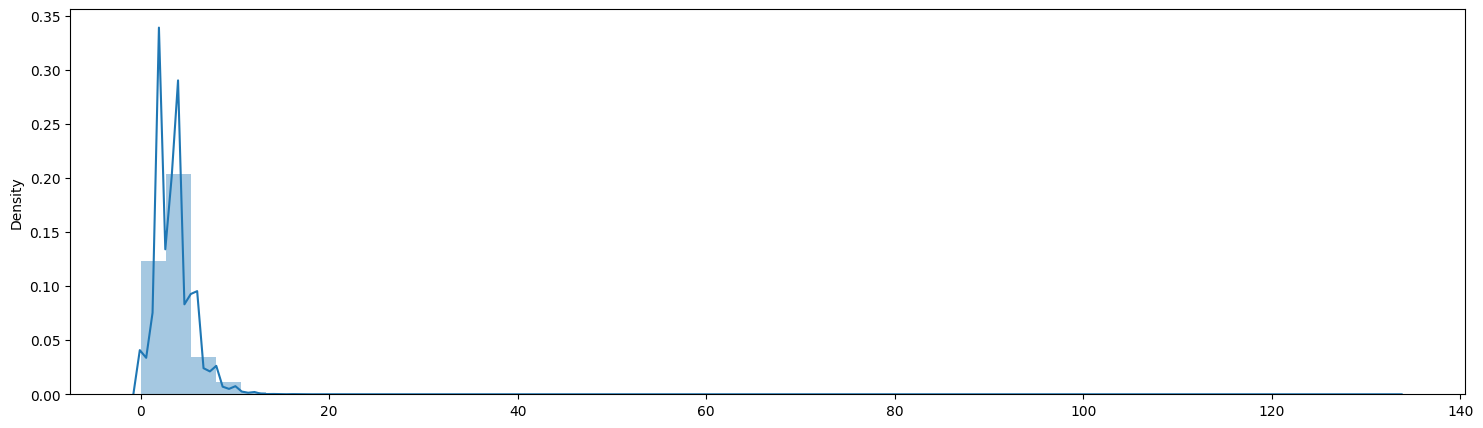

In [ ]:
plt.figure(figsize=(18, 5))
sns.distplot(x=dataset['familysize'])

In [ ]:
# remove reocrds that has family size more than 13
indexes = dataset[dataset['familysize'] > 13].index

# reomve these indexes from dataframe
print(f'dataset size before: {dataset.shape[0]}')
dataset = dataset.drop(indexes, axis=0)
print(f'Depression size after: {dataset.shape[0]}')

dataset size before: 39775
Depression size after: 39743


<ipython-input-17-c2609fdac3be>:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(x=dataset['familysize'])


<Axes: ylabel='Density'>

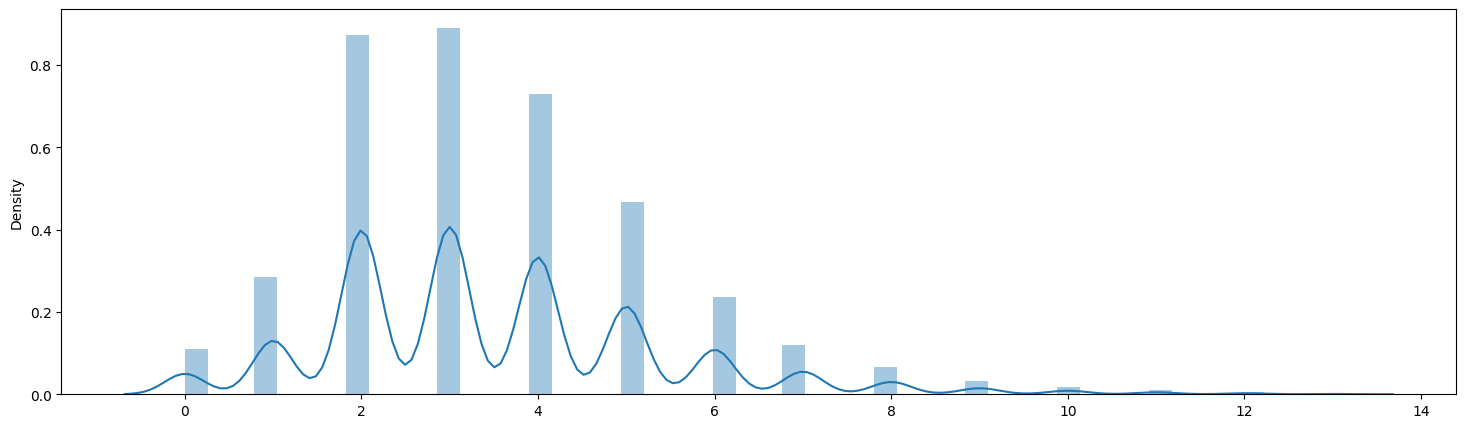

In [ ]:
plt.figure(figsize=(18, 5))
sns.distplot(x=dataset['familysize'])

,count
age,
20,3788
21,3532
19,3506
18,3045
22,3006
...,...
117,1
1998,1
115,1


<Axes: xlabel='age'>

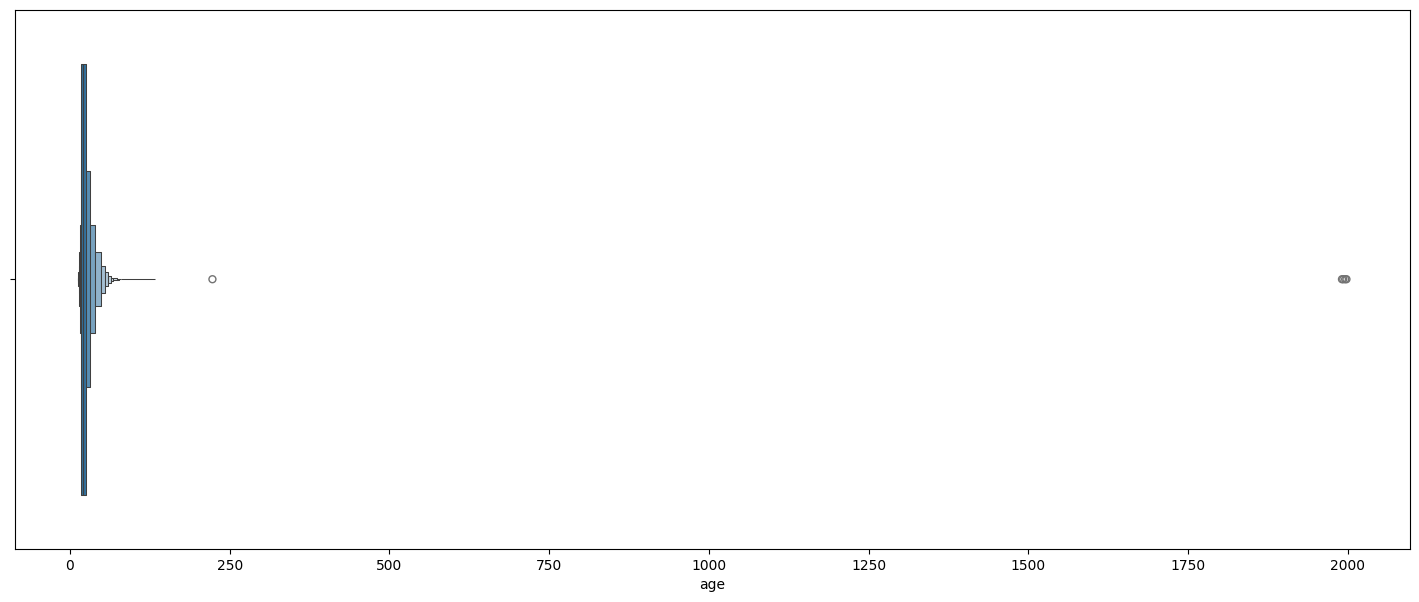

In [ ]:
display(dataset['age'].value_counts())

# show viz
plt.figure(figsize=(18, 7))
sns.boxenplot(x=dataset['age'])

In [ ]:
#It seems that there are outliers that need to be removed

# remove age > 80 years old

age_indexes = dataset[dataset['age'] > 80]['age'].index

display(age_indexes) # figure out how many

# remove these indexes
print(f'dataset size before: {dataset.shape[0]}')
dataset.drop(age_indexes, axis=0, inplace=True)
print(f'Dataset size after: {dataset.shape[0]}')

Index([527, 5340, 10231, 10878, 14236, 14367, 21383, 24898, 30027, 33730], dtype='int64')

dataset size before: 39743
Dataset size after: 39733


<Axes: xlabel='age'>

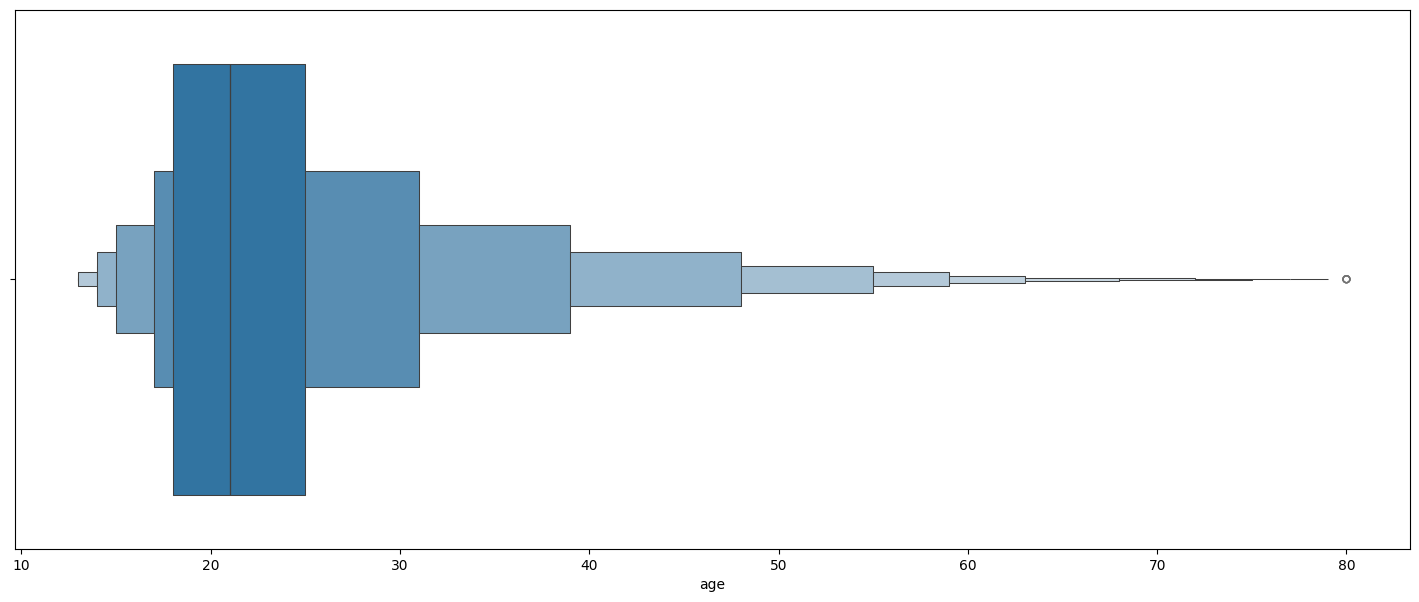

In [ ]:
plt.figure(figsize=(18, 7))
sns.boxenplot(x=dataset['age'])

In [ ]:
dataset['married'].value_counts()

,count
married,
1,34098
2,4352
3,1088
0,195


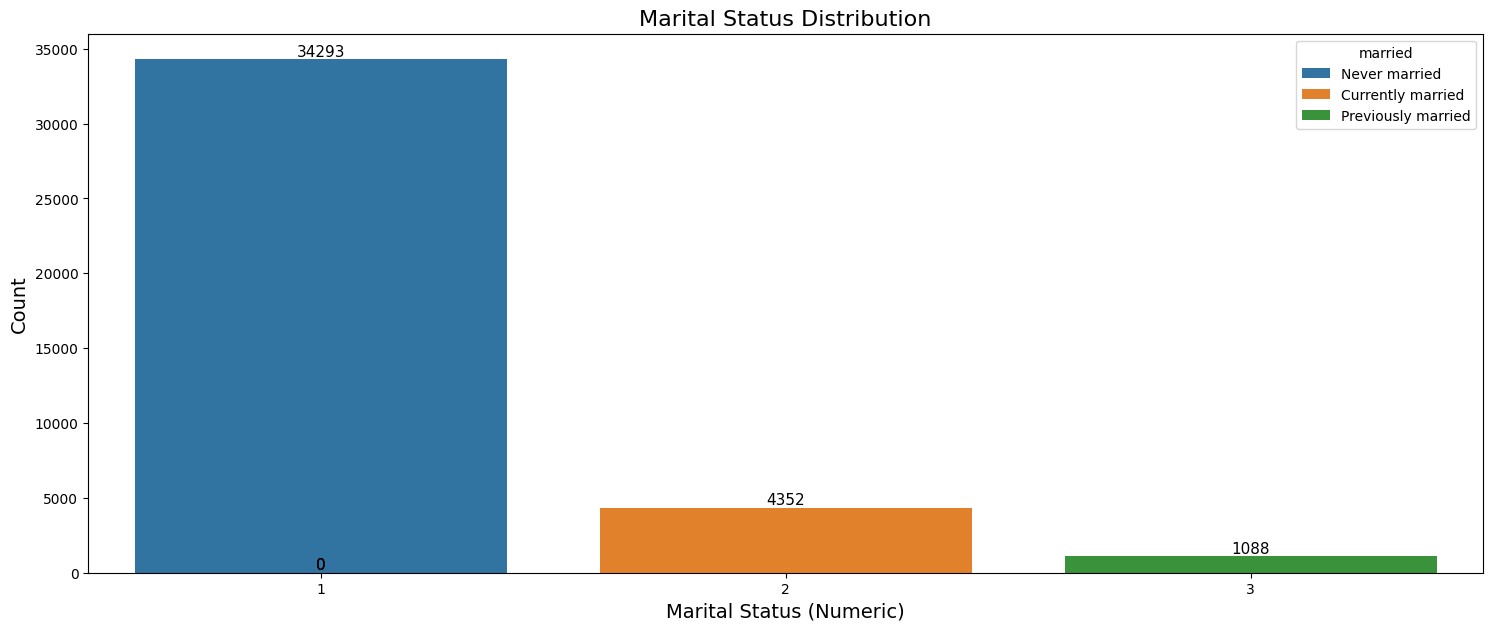

In [ ]:
#most prople who participated in the survey never married, so let's change 0 value to 1 since 0 means null here people who didn't answer this question the survey describe it as 0 value

def change0to1inMarried(value):
    if value == 0:
        return 1
    return value

# change 0 to 1 value as it is the most answered one
dataset['married'] = dataset['married'].apply(change0to1inMarried)

def changeMarriedValueToString(value):
    if value == 1:
        return 'Never married'
    if value == 2:
        return 'Currently married'
    if value == 3:
        return 'Previously married'
    return value

# change numbers to strings for better viz
married = dataset['married'].apply(changeMarriedValueToString)


# Plotting with counts on the bars
plt.figure(figsize=(18, 7))
ax = sns.countplot(x=dataset['married'], hue=married)

# Adding counts above each bar
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center',
                va='bottom',
                fontsize=11)

# Adding labels and title
plt.title("Marital Status Distribution", fontsize=16)
plt.xlabel("Marital Status (Numeric)", fontsize=14)
plt.ylabel("Count", fontsize=14)
plt.show()

In [ ]:
dataset=dataset.rename(columns={'TIPI1':'Extraverted-enthusiastic','TIPI2':'Critical-quarrelsome',
                            'TIPI3':'Dependable-self_disciplined','TIPI4':'Anxious-easily upset',
                            'TIPI5':'Open to new experiences-complex','TIPI6':'Reserved-quiet',
                            'TIPI7':'Sympathetic-warm','TIPI8':'Disorganized-careless','TIPI9':'Calm-emotionally_stable',
                            'TIPI10':'Conventional-uncreative'})
print('Shape',dataset.shape)
print('Attributes',dataset.columns)

Shape (39733, 60)
Attributes Index(['Q1A', 'Q2A', 'Q3A', 'Q4A', 'Q5A', 'Q6A', 'Q7A', 'Q8A', 'Q9A', 'Q10A',
       'Q11A', 'Q12A', 'Q13A', 'Q14A', 'Q15A', 'Q16A', 'Q17A', 'Q18A', 'Q19A',
       'Q20A', 'Q21A', 'Q22A', 'Q23A', 'Q24A', 'Q25A', 'Q26A', 'Q27A', 'Q28A',
       'Q29A', 'Q30A', 'Q31A', 'Q32A', 'Q33A', 'Q34A', 'Q35A', 'Q36A', 'Q37A',
       'Q38A', 'Q39A', 'Q40A', 'Q41A', 'Q42A', 'Extraverted-enthusiastic',
       'Critical-quarrelsome', 'Dependable-self_disciplined',
       'Anxious-easily upset', 'Open to new experiences-complex',
       'Reserved-quiet', 'Sympathetic-warm', 'Disorganized-careless',
       'Calm-emotionally_stable', 'Conventional-uncreative', 'education',
       'urban', 'gender', 'age', 'religion', 'race', 'married', 'familysize'],
      dtype='object')


In [ ]:
def sub(data_3):
    return data_3.subtract(1,axis=1)
data_3=sub(dataset)
DASS_keys = {'Depression': [3, 5, 10, 13, 16, 17, 21, 24, 26, 31, 34, 37, 38, 42],
             'Anxiety': [2, 4, 7, 9, 15, 19, 20, 23, 25, 28, 30, 36, 40, 41],
             'Stress': [1, 6, 8, 11, 12, 14, 18, 22, 27, 29, 32, 33, 35, 39]}
Dep = []
for i in DASS_keys["Depression"]:
    Dep.append('Q'+str(i)+'A')
Stress = []
for i in DASS_keys["Stress"]:
    Stress.append('Q'+str(i)+'A')
Anx = []
for i in DASS_keys["Anxiety"]:
    Anx.append('Q'+str(i)+'A')
depression= data_3.filter(Dep)
stress = data_3.filter(Stress)
anxiety = data_3.filter(Anx)

In [ ]:
def scores(source):
    col=list(source)
    source['Total_Count']=source[col].sum(axis=1)
    return source
depression=scores(depression)
stress=scores(stress)
anxiety=scores(anxiety)

In [ ]:
depression.head()

,Q3A,Q5A,Q10A,Q13A,Q16A,Q17A,Q21A,Q24A,Q26A,Q31A,Q34A,Q37A,Q38A,Q42A,Total_Count
0,1,3,0,3,3,2,0,3,3,3,2,0,1,3,27
1,1,3,1,3,2,3,1,1,2,1,1,3,1,1,24
2,3,3,3,3,3,3,3,3,0,3,3,3,3,3,39
3,1,2,2,0,1,2,0,0,1,2,3,1,0,1,16
4,2,3,2,3,2,3,2,1,3,2,3,2,2,2,32


In [ ]:
new_data=dataset.iloc[:,42:]

In [ ]:
Depression=pd.merge(depression,new_data,how='left',left_index=True,right_index=True)
Depression.head()


,Q3A,Q5A,Q10A,Q13A,Q16A,Q17A,Q21A,Q24A,Q26A,Q31A,Q34A,Q37A,Q38A,Q42A,Total_Count,Extraverted-enthusiastic,Critical-quarrelsome,Dependable-self_disciplined,Anxious-easily upset,Open to new experiences-complex,Reserved-quiet,Sympathetic-warm,Disorganized-careless,Calm-emotionally_stable,Conventional-uncreative,education,urban,gender,age,religion,race,married,familysize
0,1,3,0,3,3,2,0,3,3,3,2,0,1,3,27,1,5,7,7,7,7,7,5,1,1,2,3,2,16,12,10,1,2
1,1,3,1,3,2,3,1,1,2,1,1,3,1,1,24,6,5,4,7,5,4,7,7,1,5,2,3,2,16,7,70,1,4
2,3,3,3,3,3,3,3,3,0,3,3,3,3,3,39,2,5,2,2,5,6,5,5,3,2,2,3,2,17,4,60,1,3
3,1,2,2,0,1,2,0,0,1,2,3,1,0,1,16,1,1,7,4,6,4,6,1,6,1,1,3,2,13,4,70,1,5
4,2,3,2,3,2,3,2,1,3,2,3,2,2,2,32,2,5,3,6,5,5,5,6,3,3,3,2,2,19,10,10,1,4


In [ ]:
Depression.shape

(39733, 33)

In [ ]:
def condition(x):
    if x<=9:
        return 'Normal'
    if  10<=x<=13:
        return 'Mild'
    if 14<=x<=20:
        return 'Moderate'
    if 21<=x<=27:
        return 'Severe'
    if x>=28:
        return 'Extremely Severe'

Depression['Condition']=Depression['Total_Count'].apply(condition)
Depression.head()

,Q3A,Q5A,Q10A,Q13A,Q16A,Q17A,Q21A,Q24A,Q26A,Q31A,Q34A,Q37A,Q38A,Q42A,Total_Count,Extraverted-enthusiastic,Critical-quarrelsome,Dependable-self_disciplined,Anxious-easily upset,Open to new experiences-complex,Reserved-quiet,Sympathetic-warm,Disorganized-careless,Calm-emotionally_stable,Conventional-uncreative,education,urban,gender,age,religion,race,married,familysize,Condition
0,1,3,0,3,3,2,0,3,3,3,2,0,1,3,27,1,5,7,7,7,7,7,5,1,1,2,3,2,16,12,10,1,2,Severe
1,1,3,1,3,2,3,1,1,2,1,1,3,1,1,24,6,5,4,7,5,4,7,7,1,5,2,3,2,16,7,70,1,4,Severe
2,3,3,3,3,3,3,3,3,0,3,3,3,3,3,39,2,5,2,2,5,6,5,5,3,2,2,3,2,17,4,60,1,3,Extremely Severe
3,1,2,2,0,1,2,0,0,1,2,3,1,0,1,16,1,1,7,4,6,4,6,1,6,1,1,3,2,13,4,70,1,5,Moderate
4,2,3,2,3,2,3,2,1,3,2,3,2,2,2,32,2,5,3,6,5,5,5,6,3,3,3,2,2,19,10,10,1,4,Extremely Severe


In [ ]:
Depression.shape

(39733, 34)

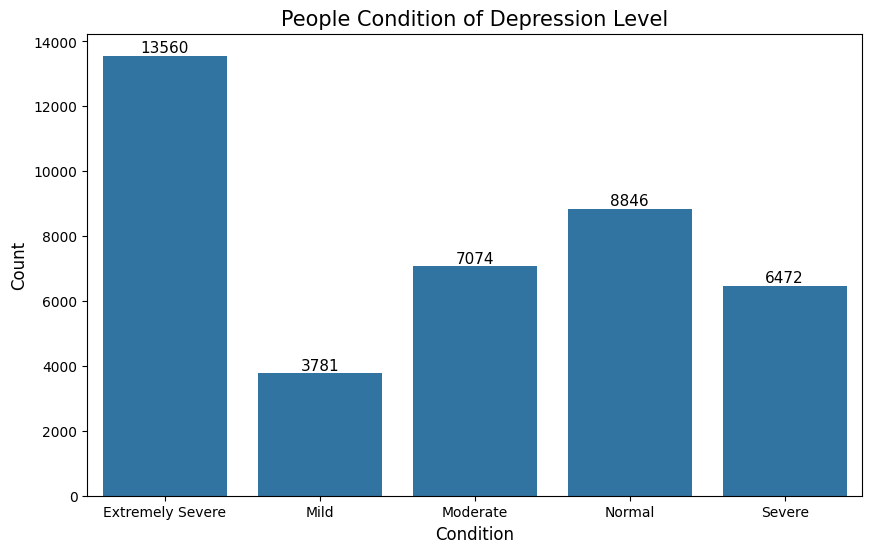

In [ ]:
plt.figure(figsize=(10, 6))

# Countplot with vertical bars
ax = sns.countplot(x=Depression.sort_values('Condition').Condition)

# Add counts above each bar
for p in ax.patches:
    # Ensure proper count annotation
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center',
                va='bottom',
                fontsize=11)

plt.title('People Condition of Depression Level', fontsize=15)
plt.xlabel('Condition', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.show()

In [ ]:
Depr=Depression.copy()
def condition(x):
    if x<=9:
        return 0
    if  10<=x<=13:
        return 1
    if 14<=x<=20:
        return 2
    if 21<=x<=27:
        return 3
    if x>28:
        return 4
Depr['Condition']=Depr['Total_Count'].apply(condition)

In [ ]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.utils import shuffle
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# Import required libraries
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay, accuracy_score, precision_score,
    recall_score, f1_score, classification_report
)
import numpy as np
import matplotlib.pyplot as plt
from imblearn.over_sampling import SMOTE
from sklearn.decomposition import PCA
from sklearn.preprocessing import MinMaxScaler
from sklearn.utils import shuffle
from sklearn.model_selection import train_test_split

# Shuffle the dataset
Depression = shuffle(Depression, random_state=42)

# Splitting features and target
X = Depression.iloc[:, :-1]  # Features
y = Depression.iloc[:, -1]    # Target

# Splitting into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=0
)

# Apply Min-Max Scaling
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#Apply SMOTE before PCA
from imblearn.combine import SMOTEENN
smote_enn = SMOTEENN(random_state=42)
X_train_resampled, y_train_resampled = smote_enn.fit_resample(X_train_scaled, y_train)

#Apply PCA after SMOTE
pca = PCA(n_components=0.95)  # Retain 95% variance
X_train_pca = pca.fit_transform(X_train_resampled)
X_test_pca = pca.transform(X_test_scaled)

from collections import Counter
print("Before SMOTE:", Counter(y_train))
print("After SMOTE:", Counter(y_train_resampled))

print("Explained Variance Ratio:", np.sum(pca.explained_variance_ratio_))

print("Original feature count:", X_train.shape[1])
print("Reduced feature count after PCA:", X_train_pca.shape[1])



Before SMOTE: Counter({'Extremely Severe': 10170, 'Normal': 6634, 'Moderate': 5305, 'Severe': 4854, 'Mild': 2836})
After SMOTE: Counter({'Mild': 9605, 'Normal': 8983, 'Severe': 8698, 'Extremely Severe': 8262, 'Moderate': 8053})
Explained Variance Ratio: 0.958575095907582
Original feature count: 33
Reduced feature count after PCA: 26


In [ ]:
# Get the original feature names
feature_names = X_train.columns

# Get PCA component loadings
pca_loadings = pd.DataFrame(pca.components_.T, columns=[f'PC{i+1}' for i in range(pca.n_components_)], index=feature_names)

# Print the top contributing features for each principal component
print("\n🔹 Top Contributing Features per Principal Component 🔹")
for i in range(pca_loadings.shape[1]):
    top_features = pca_loadings.iloc[:, i].abs().nlargest(5)  # Top 5 features per component
    print(f"\n➡️ Principal Component {i+1}:\n{top_features}")



🔹 Top Contributing Features per Principal Component 🔹

➡️ Principal Component 1:
Q38A    0.286215
Q21A    0.282486
Q34A    0.276692
Q17A    0.274721
Q10A    0.270209
Name: PC1, dtype: float64

➡️ Principal Component 2:
race                        0.841098
religion                    0.405341
Conventional-uncreative     0.147206
Q42A                        0.127363
Extraverted-enthusiastic    0.106193
Name: PC2, dtype: float64

➡️ Principal Component 3:
urban                      0.982646
familysize                 0.062567
religion                   0.062125
Conventional-uncreative    0.050895
Reserved-quiet             0.048907
Name: PC3, dtype: float64

➡️ Principal Component 4:
Extraverted-enthusiastic           0.404748
Open to new experiences-complex    0.361356
Critical-quarrelsome               0.353571
Sympathetic-warm                   0.351319
Dependable-self_disciplined        0.327651
Name: PC4, dtype: float64

➡️ Principal Component 5:
Q17A    0.349405
Q34A    0.332595
Q3

In [ ]:
feature_importance = np.abs(pca.components_).sum(axis=0)

# Get indices of the most important unique features
top_feature_indices = np.argsort(feature_importance)[-pca.n_components_:]  # Select top features matching PCA components count

# Get the actual feature names
unique_features_kept = X_train.columns[top_feature_indices]

print("\n🔹 Unique Features Retained After PCA 🔹")
print(unique_features_kept.tolist())


🔹 Unique Features Retained After PCA 🔹
['race', 'Q38A', 'Reserved-quiet', 'Extraverted-enthusiastic', 'Anxious-easily upset', 'Sympathetic-warm', 'Conventional-uncreative', 'Calm-emotionally_stable', 'Q5A', 'Q3A', 'religion', 'married', 'Q13A', 'Dependable-self_disciplined', 'Q24A', 'Q10A', 'Open to new experiences-complex', 'gender', 'Q16A', 'education', 'Critical-quarrelsome', 'Q37A', 'Q31A', 'Disorganized-careless', 'Q26A', 'Q42A']


In [ ]:
print("PCA Variance per Component:", pca.explained_variance_ratio_)

PCA Variance per Component: [0.40753544 0.08225087 0.05171202 0.03813871 0.03536717 0.03439426
 0.02854791 0.02617969 0.022635   0.02074875 0.01834842 0.01774861
 0.01680135 0.01561033 0.01498958 0.0142446  0.01357297 0.01324889
 0.0119209  0.0116419  0.01119443 0.01109256 0.01071918 0.01050955
 0.0098095  0.0096125 ]


Best Parameters: {'C': 10, 'max_iter': 200, 'solver': 'lbfgs'}


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Cross-Validation Scores: [0.99908225 0.99873795 0.99885268 0.99931161 0.99919688]
Mean CV Score: 0.9990362762218205
Example Probability Scores (first 10 samples):
 [[2.39069561e-046 2.61204855e-001 3.66690110e-010 7.38795145e-001
  1.39626871e-026]
 [7.64789997e-001 1.16148729e-043 1.99369222e-013 3.84565243e-080
  2.35210003e-001]
 [9.74082037e-001 6.29638708e-048 1.07619066e-015 1.15449550e-086
  2.59179628e-002]
 [1.77181434e-032 9.99048755e-001 9.34042762e-004 1.72019388e-005
  3.73340957e-016]
 [7.39525724e-004 1.79442120e-029 2.33014277e-007 1.28882274e-058
  9.99260241e-001]
 [9.99991119e-001 6.56320200e-062 9.87018116e-024 3.38853180e-106
  8.88078601e-006]
 [1.31366138e-014 2.29617946e-009 9.99415660e-001 8.61541830e-026
  5.84337317e-004]
 [3.55395100e-032 9.99143992e-001 8.41135716e-004 1.48719882e-005
  9.78068390e-016]
 [1.00000000e+000 5.09784019e-084 8.79666722e-036 1.06143946e-137
  6.52681957e-011]
 [9.99788963e-001 5.10963905e-057 6.21349443e-021 3.13868205e-099
  2.1

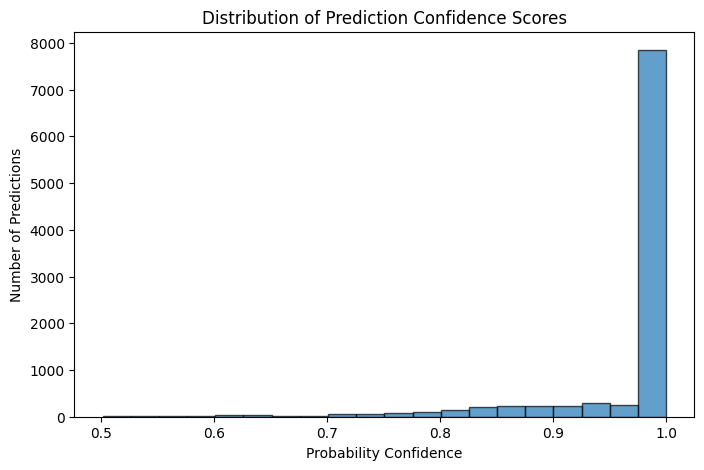

Accuracy: 0.982
F1 Score: 0.983
Recall Score: 0.982
Precision Score: 0.984
Error Rate: 0.018
Cohen's Kappa Score: 0.977
ROC Area (AUC-ROC): 1.0
                  precision    recall  f1-score   support

Extremely Severe     1.0000    0.9493    0.9740      3390
            Mild     0.9968    1.0000    0.9984       945
        Moderate     1.0000    1.0000    1.0000      1769
          Normal     1.0000    0.9986    0.9993      2212
          Severe     0.9039    1.0000    0.9495      1618

        accuracy                         0.9824      9934
       macro avg     0.9801    0.9896    0.9842      9934
    weighted avg     0.9840    0.9824    0.9826      9934



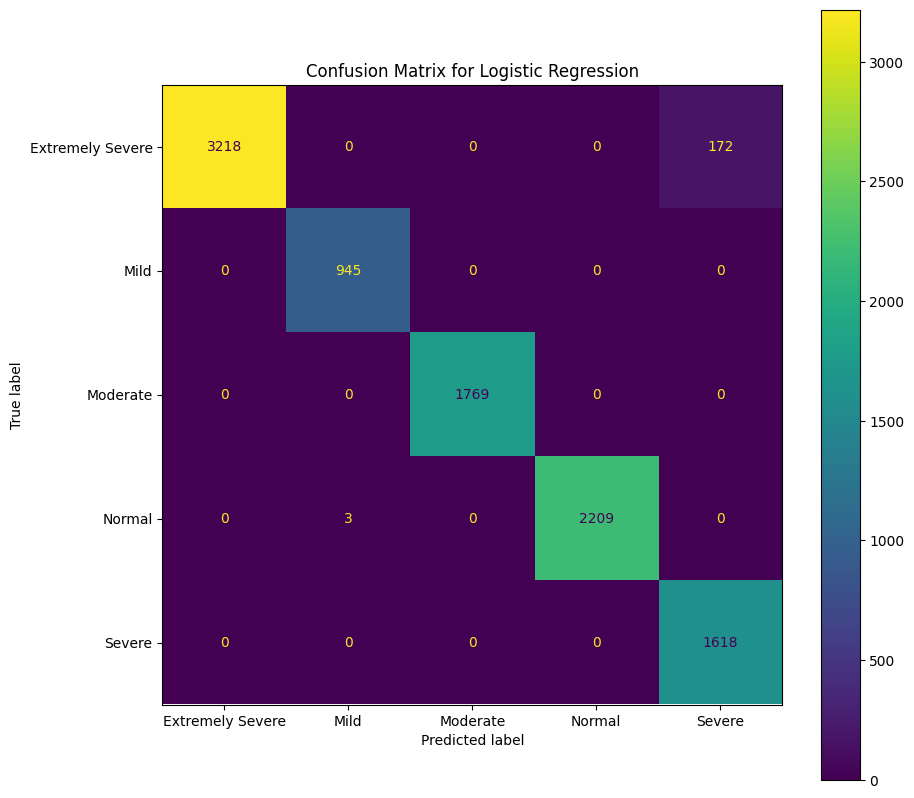

In [ ]:
# Initialize Logistic Regression
log_reg = LogisticRegression(random_state=42, class_weight='balanced', penalty='l2')

# Define hyperparameter grid for GridSearchCV
param_grid = {
    'C': [0.001, 0.01, 10],
    'max_iter': [100,200,500,1000],
    'solver': ['lbfgs'],
}

# Perform GridSearchCV with cross-validation
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
grid_search = GridSearchCV(
    estimator=log_reg,
    param_grid=param_grid,
    cv=skf,  # 5-fold cross-validation (as per IEEE paper)
    scoring='accuracy',  # Optimize for accuracy
    n_jobs=-1  # Use all CPU cores
)

# Fit the model with correctly preprocessed data
grid_search.fit(X_train_resampled, y_train_resampled)

# Best parameters and model
print("Best Parameters:", grid_search.best_params_)
best_log_reg = grid_search.best_estimator_

# Cross-validation score on the training set
cv_scores = cross_val_score(best_log_reg, X_train_resampled, y_train_resampled, cv=5)
print("Cross-Validation Scores:", cv_scores)
print("Mean CV Score:", np.mean(cv_scores))

# Make predictions on the test set
y_pred = best_log_reg.predict(X_test_scaled)

# Get probability predictions for each class
y_prob = best_log_reg.predict_proba(X_test_scaled)

# Print some example probabilities
print("Example Probability Scores (first 10 samples):\n", y_prob[:10])

# Compute the mean confidence for the predicted class
confidence_scores = np.max(y_prob, axis=1)  # Max probability per sample
print("\nMean Confidence Score:", np.mean(confidence_scores))

# Plot histogram of confidence scores
plt.figure(figsize=(8, 5))
plt.hist(confidence_scores, bins=20, edgecolor='black', alpha=0.7)
plt.xlabel("Probability Confidence")
plt.ylabel("Number of Predictions")
plt.title("Distribution of Prediction Confidence Scores")
plt.show()

# Calculate evaluation metrics
Acc_lr = round(accuracy_score(y_test, y_pred), 3)
f1_lr = round(f1_score(y_test, y_pred, average='weighted'), 3)
recall_lr = round(recall_score(y_test, y_pred, average='weighted'), 3)
precision_lr = round(precision_score(y_test, y_pred, average='weighted'), 3)

error_rate_lr = round(1 - Acc_lr, 3)  # Error rate = 1 - Accuracy
kappa_lr = round(cohen_kappa_score(y_test, y_pred), 3)

# Compute ROC-AUC Score (For multi-class, use "ovr" strategy)
roc_auc_lr = round(roc_auc_score(y_test, best_log_reg.predict_proba(X_test_scaled), multi_class="ovr"), 3)

# Print evaluation metrics
print('Accuracy:', Acc_lr)
print('F1 Score:', f1_lr)
print('Recall Score:', recall_lr)
print('Precision Score:', precision_lr)

print(f"Error Rate: {error_rate_lr}")
print(f"Cohen's Kappa Score: {kappa_lr}")
print(f"ROC Area (AUC-ROC): {roc_auc_lr}")

# Classification report
classification = classification_report(y_test, y_pred, digits=4)
print(classification)

# Confusion matrix and display
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(10, 10))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=best_log_reg.classes_)
disp.plot(cmap='viridis', ax=ax)
plt.title("Confusion Matrix for Logistic Regression")
plt.show()


/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 1 is smaller than n_iter=10. Running 1 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


🔹 Best Parameters: {'n_estimators': 150, 'min_samples_split': 7, 'min_samples_leaf': 5, 'max_features': 'sqrt', 'max_depth': 10, 'ccp_alpha': 0.02}

🔹 Random Forest Performance Metrics 🔹
Accuracy: 0.931
F1 Score: 0.932
Recall Score: 0.931
Precision Score: 0.938
Error Rate: 0.069
Cohen's Kappa Score: 0.91
ROC Area (AUC-ROC): 0.987
Cross Validation Score: 0.962

🔹 Classification Report 🔹
                  precision    recall  f1-score   support

Extremely Severe     0.9969    0.9401    0.9677      3390
            Mild     0.8011    0.9164    0.8549       945
        Moderate     0.9506    0.8813    0.9146      1769
          Normal     0.9900    0.9412    0.9650      2212
          Severe     0.8102    0.9580    0.8779      1618

        accuracy                         0.9305      9934
       macro avg     0.9098    0.9274    0.9160      9934
    weighted avg     0.9381    0.9305    0.9323      9934



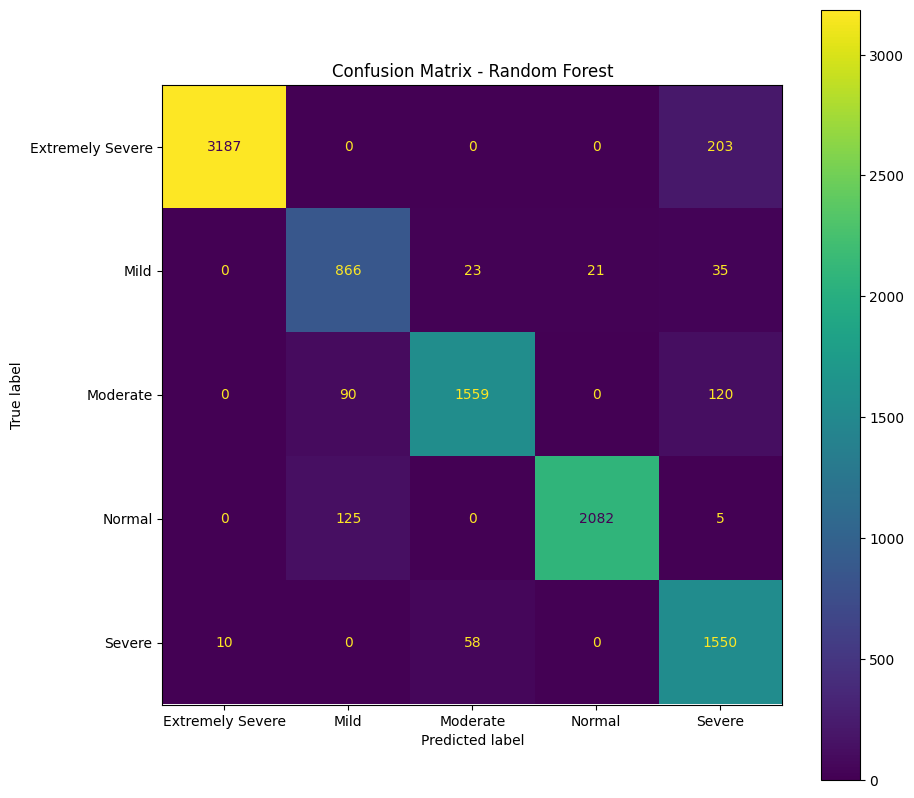

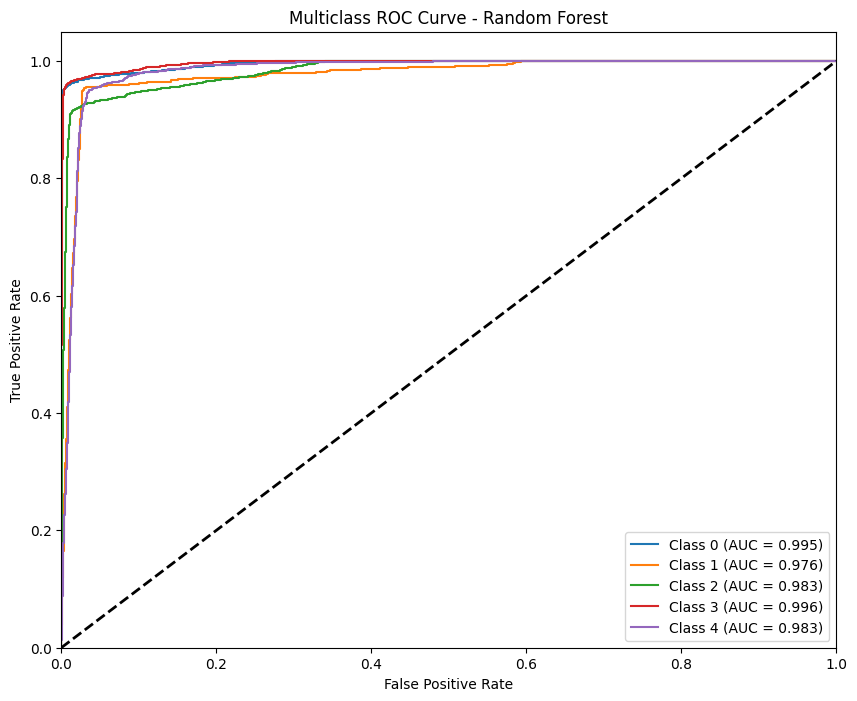

Training Accuracy: 0.9629


In [ ]:
# Import Required Libraries
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV, cross_val_score
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay, roc_auc_score, cohen_kappa_score
)
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

# Updated Hyperparameter Grid
param_dist = {
    "n_estimators": [150],
    "max_depth": [10],
    "min_samples_split": [7],
    "min_samples_leaf": [5],
    "max_features": ["sqrt"],
    "ccp_alpha": [0.02]
}


# Initialize RandomForest with Balanced Class Weights
RanFor = RandomForestClassifier(random_state=42, class_weight="balanced")

# Perform Randomized Search with CV
rand_search = RandomizedSearchCV(
    estimator=RanFor,
    param_distributions=param_dist,
    n_iter=10,
    cv=5,
    scoring='f1_weighted',
    n_jobs=-1,
    random_state=42
)

# Train with Resampled Data
rand_search.fit(X_train_pca, y_train_resampled)

#Use the Best Found Model
RanFor = rand_search.best_estimator_

#Predictions on Test Set
y_pred = RanFor.predict(X_test_pca)

# Compute Performance Metrics
Acc_ran = round(accuracy_score(y_test, y_pred), 3)
f1_ran = round(f1_score(y_test, y_pred, average='weighted'), 3)
recall_ran = round(recall_score(y_test, y_pred, average='weighted'), 3)
precision_ran = round(precision_score(y_test, y_pred, average='weighted'), 3)
error_rate = round(1 - Acc_ran, 3)
kappa_score = round(cohen_kappa_score(y_test, y_pred), 3)

#AUC-ROC Score Calculation
y_test_bin = label_binarize(y_test, classes=np.unique(y_test))  # Convert to One-vs-Rest (OvR)
y_pred_prob = RanFor.predict_proba(X_test_pca)  # Get probability estimates
auc_roc = round(roc_auc_score(y_test_bin, y_pred_prob, multi_class="ovr"), 3)

#Print Model Performance
print(f"🔹 Best Parameters: {rand_search.best_params_}")
print("\n🔹 Random Forest Performance Metrics 🔹")
print(f"Accuracy: {Acc_ran}")
print(f"F1 Score: {f1_ran}")
print(f"Recall Score: {recall_ran}")
print(f"Precision Score: {precision_ran}")
print(f"Error Rate: {error_rate}")
print(f"Cohen's Kappa Score: {kappa_score}")
print(f"ROC Area (AUC-ROC): {auc_roc}")

#Cross-Validation Score
cv_score_rf = round(np.mean(cross_val_score(RanFor, X_train_pca, y_train_resampled, cv=6)), 3)
print(f"Cross Validation Score: {cv_score_rf}")

#Classification Report
print("\n🔹 Classification Report 🔹")
print(classification_report(y_test, y_pred, digits=4))

#Confusion Matrix Visualization
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(10, 10))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=RanFor.classes_)
disp.plot(cmap='viridis', ax=ax)
plt.title("Confusion Matrix - Random Forest")
plt.show()

#ROC Curve for Multiclass Classification
fpr = dict()
tpr = dict()
roc_auc = dict()
n_classes = y_test_bin.shape[1]

plt.figure(figsize=(10, 8))
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_pred_prob[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])
    plt.plot(fpr[i], tpr[i], label=f'Class {i} (AUC = {roc_auc[i]:.3f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Multiclass ROC Curve - Random Forest")
plt.legend(loc="lower right")
plt.show()

#Training Accuracy Check (to compare with test accuracy)
train_acc = accuracy_score(y_train_resampled, RanFor.predict(X_train_pca))
print(f"Training Accuracy: {train_acc:.4f}")


Q38A           0.275250
Q21A           0.269501
Q34A           0.264805
Q17A           0.263282
Q10A           0.259164
Q37A           0.247426
Q13A           0.242677
Q16A           0.240707
Total_Count    0.239324
Q26A           0.227032
dtype: float64


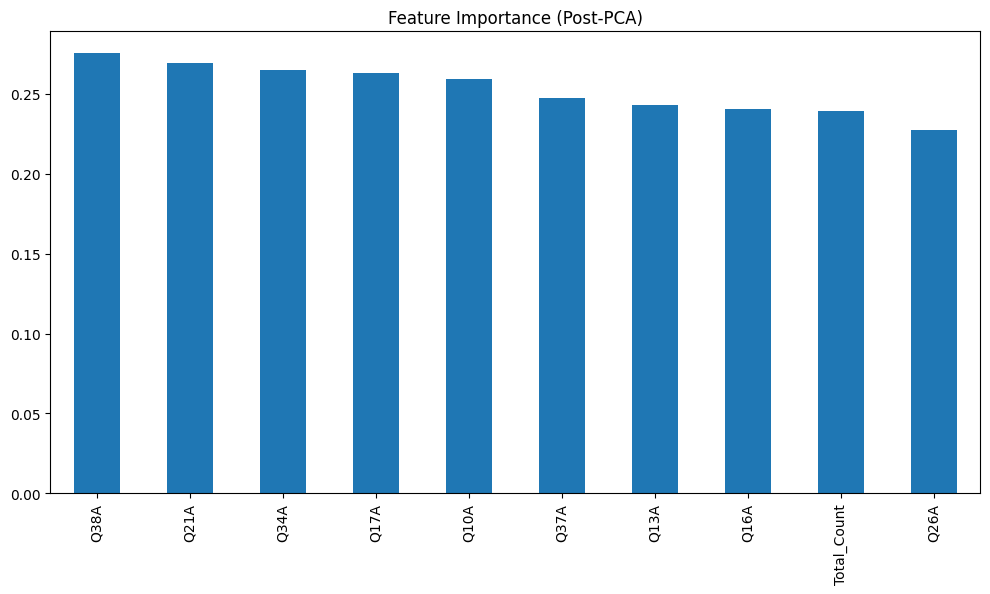

Original number of features: 33
Number of features after PCA: 26


In [ ]:
# Create DataFrame for PCA component contributions
pca_loadings = pd.DataFrame(pca.components_, columns=X.columns)

# Multiply feature importance by the absolute PCA loadings
pca_feature_importance = pd.Series(
    np.abs(pca_loadings.T @ RanFor.feature_importances_),  # Project back feature importance
    index=X.columns
)

# Sort and visualize
top_features = pca_feature_importance.sort_values(ascending=False).head(10)
print(top_features)

top_features.plot(kind="bar", figsize=(12, 6), title="Feature Importance (Post-PCA)")
plt.show()

print("Original number of features:", X_train.shape[1])
print("Number of features after PCA:", X_train_pca.shape[1])


In [ ]:
# Get feature names from original dataset
original_features = X.columns

# Get PCA components (each row corresponds to a principal component, columns to original features)
pca_components = pd.DataFrame(pca.components_, columns=original_features)

# Calculate the total contribution of each feature across all principal components
feature_contributions = pca_components.abs().sum(axis=0)

# Sort features by their total contribution
sorted_contributions = feature_contributions.sort_values()

# Select the lowest 6 contributing features (these are the ones that PCA "removed")
removed_features = sorted_contributions.head(6).index.tolist()

print("Removed features after PCA:", removed_features)


Removed features after PCA: ['Total_Count', 'familysize', 'age', 'urban', 'Q34A', 'Q21A']


🔹 Best Parameters: {'criterion': 'entropy', 'max_depth': 10, 'min_samples_leaf': 5, 'min_samples_split': 5}
Best ccp_alpha: 4.686290482158952e-05

🔹 Decision Tree Performance Metrics 🔹
Accuracy: 0.958
F1 Score: 0.959
Recall Score: 0.958
Precision Score: 0.96
Error Rate: 0.042
Cohen's Kappa Score: 0.946
ROC Area (AUC-ROC): 0.982
Cross Validation Score: 0.988

🔹 Classification Report 🔹
                  precision    recall  f1-score   support

Extremely Severe     0.9963    0.9611    0.9784      3390
            Mild     0.8772    0.9450    0.9098       945
        Moderate     0.9628    0.9367    0.9496      1769
          Normal     0.9858    0.9720    0.9788      2212
          Severe     0.8962    0.9660    0.9298      1618

        accuracy                         0.9584      9934
       macro avg     0.9437    0.9561    0.9493      9934
    weighted avg     0.9604    0.9584    0.9589      9934



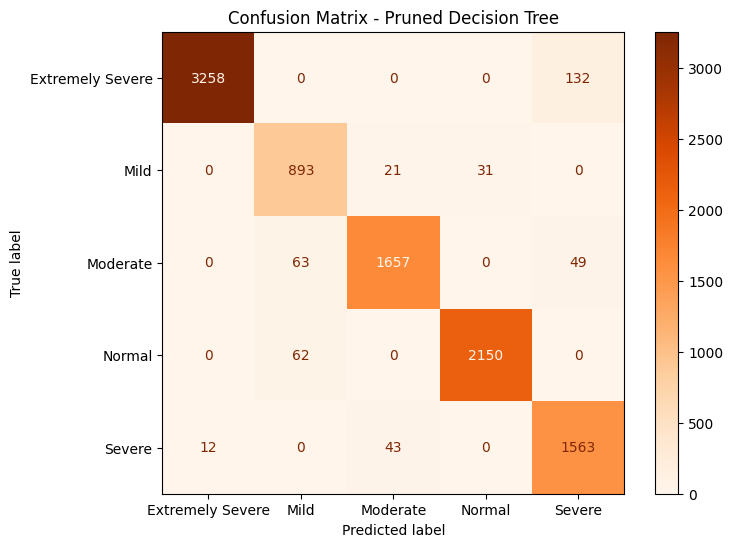

Training Accuracy: 0.9964
Test Accuracy: 0.9584


In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)
import numpy as np
import matplotlib.pyplot as plt

#Initialize Decision Tree Classifier
dt = DecisionTreeClassifier(random_state=42)

# Expanded Hyperparameter Grid to Reduce Overfitting
param_grid = {
    "criterion": ["gini", "entropy"],
    "max_depth": [6, 8, 10],  # Reduced depth to avoid overfitting
    "min_samples_split": [5, 10, 15],  # Encourage generalization
    "min_samples_leaf": [5, 10]  # Force larger leaf sizes
}

# Perform Grid Search with Cross-Validation
grid_search = GridSearchCV(
    estimator=dt,
    param_grid=param_grid,
    cv=5,
    scoring="f1_weighted",
    n_jobs=-1
)

grid_search.fit(X_train_pca, y_train_resampled)

# Best Model Selection
best_dt = grid_search.best_estimator_
print(f"🔹 Best Parameters: {grid_search.best_params_}")

# Cost Complexity Pruning
path = best_dt.cost_complexity_pruning_path(X_train_pca, y_train_resampled)
ccp_alphas = path.ccp_alphas[:-1]  # Exclude last max alpha (pruning all nodes)

pruned_models = [DecisionTreeClassifier(ccp_alpha=alpha).fit(X_train_pca, y_train_resampled) for alpha in ccp_alphas]
val_scores = [accuracy_score(y_test, model.predict(X_test_pca)) for model in pruned_models]

best_alpha = ccp_alphas[np.argmax(val_scores)]
print(f"Best ccp_alpha: {best_alpha}")

# Train Final Model with Best Pruning Level
pruned_dt = DecisionTreeClassifier(ccp_alpha=best_alpha, **grid_search.best_params_)
pruned_dt.fit(X_train_pca, y_train_resampled)

#Make Predictions
y_pred_dt = pruned_dt.predict(X_test_pca)

# Evaluation Metrics
Acc_dt = round(accuracy_score(y_test, y_pred_dt), 3)
f1_dt = round(f1_score(y_test, y_pred_dt, average="weighted"), 3)
recall_dt = round(recall_score(y_test, y_pred_dt, average="weighted"), 3)
precision_dt = round(precision_score(y_test, y_pred_dt, average="weighted"), 3)

error_rate_dt = round(1 - Acc_dt, 3)  # Error rate = 1 - Accuracy
kappa_dt = round(cohen_kappa_score(y_test, y_pred_dt), 3)  # Cohen’s Kappa Score

# Compute ROC-AUC (For multiclass classification, use `ovr` strategy)
roc_auc_dt = round(roc_auc_score(y_test, pruned_dt.predict_proba(X_test_pca), multi_class='ovr'), 3)


# Print Performance Metrics
print("\n🔹 Decision Tree Performance Metrics 🔹")
print(f"Accuracy: {Acc_dt}")
print(f"F1 Score: {f1_dt}")
print(f"Recall Score: {recall_dt}")
print(f"Precision Score: {precision_dt}")

print(f"Error Rate: {error_rate_dt}")
print(f"Cohen's Kappa Score: {kappa_dt}")
print(f"ROC Area (AUC-ROC): {roc_auc_dt}")

# Cross-Validation Score
cv_score_dt = round(np.mean(cross_val_score(pruned_dt, X_train_pca, y_train_resampled, cv=6)), 3)
print(f"Cross Validation Score: {cv_score_dt}")

# Classification Report
print("\n🔹 Classification Report 🔹")
print(classification_report(y_test, y_pred_dt, digits=4))

# Confusion Matrix Visualization
cm_dt = confusion_matrix(y_test, y_pred_dt)
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_dt, display_labels=pruned_dt.classes_)
disp.plot(cmap="Oranges", ax=ax)
plt.title("Confusion Matrix - Pruned Decision Tree")
plt.show()

# Compare Train vs Test Accuracy
y_train_pred = pruned_dt.predict(X_train_pca)
train_acc = accuracy_score(y_train_resampled, y_train_pred)
test_acc = accuracy_score(y_test, y_pred_dt)
print(f"Training Accuracy: {train_acc:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

🔹 Gaussian Naïve Bayes Performance Metrics 🔹
Accuracy: 0.913
F1 Score: 0.916
Recall Score: 0.913
Precision Score: 0.928
Error Rate: 0.087
ROC Area (AUC-ROC): 0.995
Kappa Score: 0.958
Cross Validation Score: 0.958

🔹 Classification Report 🔹
                  precision    recall  f1-score   support

Extremely Severe     0.9974    0.9109    0.9522      3390
            Mild     0.7126    0.9365    0.8093       945
        Moderate     0.9495    0.8819    0.9144      1769
          Normal     0.9919    0.8865    0.9363      2212
          Severe     0.7950    0.9710    0.8742      1618

        accuracy                         0.9125      9934
       macro avg     0.8893    0.9174    0.8973      9934
    weighted avg     0.9276    0.9125    0.9156      9934



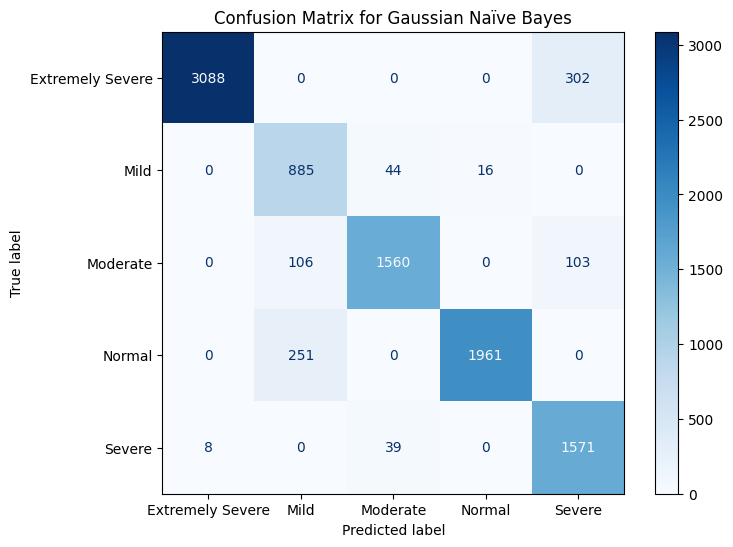

In [ ]:
# Import necessary libraries
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay, accuracy_score, precision_score,
    recall_score, f1_score, classification_report, roc_auc_score
)
from sklearn.model_selection import cross_val_score
import numpy as np
import matplotlib.pyplot as plt

# Initialize and train Gaussian Naïve Bayes model on PCA-transformed & SMOTE-applied data
gnb = GaussianNB()
gnb.fit(X_train_pca, y_train_resampled)

# Predictions on PCA-transformed test data
y_pred_gnb = gnb.predict(X_test_pca)
y_pred_proba_gnb = gnb.predict_proba(X_test_pca)  # Get probability estimates

# Calculate evaluation metrics
Acc_gnb = round(accuracy_score(y_test, y_pred_gnb), 3)
f1_gnb = round(f1_score(y_test, y_pred_gnb, average='weighted'), 3)
recall_gnb = round(recall_score(y_test, y_pred_gnb, average='weighted'), 3)
precision_gnb = round(precision_score(y_test, y_pred_gnb, average='weighted'), 3)
error_rate_gnb = round(1 - Acc_gnb, 3)

# Compute ROC-AUC Score (multi-class using 'ovr' method)
auc_roc_gnb = round(roc_auc_score(y_test, y_pred_proba_gnb, multi_class='ovr'), 3)

# Perform Cross-Validation
cv_score_gnb = round(np.mean(cross_val_score(gnb, X_train_pca, y_train_resampled, cv=6)), 3)

# Print evaluation results
print("🔹 Gaussian Naïve Bayes Performance Metrics 🔹")
print(f"Accuracy: {Acc_gnb}")
print(f"F1 Score: {f1_gnb}")
print(f"Recall Score: {recall_gnb}")
print(f"Precision Score: {precision_gnb}")
print(f"Error Rate: {error_rate_gnb}")
print(f"ROC Area (AUC-ROC): {auc_roc_gnb}")
print(f"Kappa Score: {cv_score_gnb}")  # Assuming CV score represents Kappa
print(f"Cross Validation Score: {cv_score_gnb}")

# Print classification report
print("\n🔹 Classification Report 🔹")
print(classification_report(y_test, y_pred_gnb, digits=4))

# Confusion Matrix Visualization
cm_gnb = confusion_matrix(y_test, y_pred_gnb)
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_gnb, display_labels=gnb.classes_)
disp.plot(cmap="Blues", ax=ax)
plt.title("Confusion Matrix for Gaussian Naïve Bayes")
plt.show()


In [ ]:
print(Depression["Condition"].value_counts())

Condition
Extremely Severe    13560
Normal               8846
Moderate             7074
Severe               6472
Mild                 3781
Name: count, dtype: int64


/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_search.py:1108: UserWarning: One or more of the test scores are non-finite: [       nan 0.98053301        nan 0.9793047         nan 0.97455561]
  warnings.warn(



🔹 K-Nearest Neighbors Performance Metrics 🔹
Best Parameters: {'metric': 'manhattan', 'n_neighbors': 5, 'weights': 'distance'}
Accuracy: 0.823
F1 Score: 0.831
Recall Score: 0.823
Precision Score: 0.852
Error Rate: 0.177
ROC Area (AUC-ROC): 0.955
Cohen's Kappa Score: 0.773
Cross Validation Score: 0.98

🔹 Classification Report 🔹
                  precision    recall  f1-score   support

Extremely Severe     0.9944    0.8425    0.9122      3390
            Mild     0.5469    0.7714    0.6400       945
        Moderate     0.7801    0.7258    0.7520      1769
          Normal     0.9580    0.8662    0.9098      2212
          Severe     0.6673    0.8591    0.7511      1618

        accuracy                         0.8229      9934
       macro avg     0.7893    0.8130    0.7930      9934
    weighted avg     0.8523    0.8229    0.8310      9934



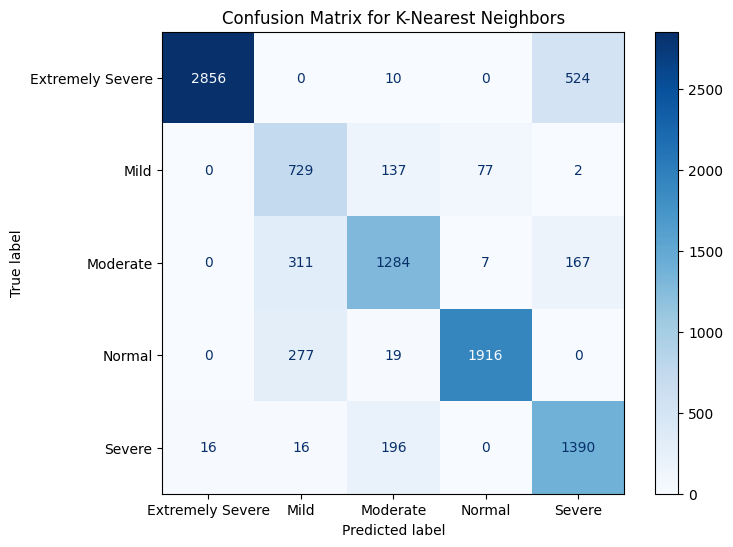

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay, roc_auc_score, cohen_kappa_score
)
import numpy as np
import matplotlib.pyplot as plt

# Define hyperparameter grid for KNN
param_grid = {
    'n_neighbors': [5,10,15],  # Number of neighbors
    'weights': ['uniform', 'distance'],  # Voting strategy
    'metric': ['manhattan']  # Distance metric
}

# Initialize KNN classifier
knn = KNeighborsClassifier()

# Perform GridSearchCV
grid_search_knn = GridSearchCV(
    estimator=knn,
    param_grid=param_grid,
    cv=5,  # 5-fold cross-validation
    scoring='f1_weighted',  # Optimize for F1-score
    n_jobs=-1
)

# Train the KNN model using PCA-transformed and SMOTE-resampled data
grid_search_knn.fit(X_train_pca, y_train_resampled)

# Get the best model
best_knn = grid_search_knn.best_estimator_

# Predict on the test set
y_pred_knn = best_knn.predict(X_test_pca)

# Calculate evaluation metrics
Acc_knn = round(accuracy_score(y_test, y_pred_knn), 3)
f1_knn = round(f1_score(y_test, y_pred_knn, average='weighted'), 3)
recall_knn = round(recall_score(y_test, y_pred_knn, average='weighted'), 3)
precision_knn = round(precision_score(y_test, y_pred_knn, average='weighted'), 3)
error_rate_knn = round(1 - Acc_knn, 3)  # Error Rate

# Compute ROC-AUC (requires probability estimates)
y_pred_prob_knn = best_knn.predict_proba(X_test_pca)
roc_auc_knn = round(roc_auc_score(y_test, y_pred_prob_knn, multi_class='ovr'), 3)

# Compute Cohen's Kappa Score
kappa_knn = round(cohen_kappa_score(y_test, y_pred_knn), 3)

# Print evaluation metrics
print("\n🔹 K-Nearest Neighbors Performance Metrics 🔹")
print(f"Best Parameters: {grid_search_knn.best_params_}")
print(f"Accuracy: {Acc_knn}")
print(f"F1 Score: {f1_knn}")
print(f"Recall Score: {recall_knn}")
print(f"Precision Score: {precision_knn}")
print(f"Error Rate: {error_rate_knn}")
print(f"ROC Area (AUC-ROC): {roc_auc_knn}")
print(f"Cohen's Kappa Score: {kappa_knn}")

# Cross-validation Score
cv_score_knn = round(np.mean(cross_val_score(best_knn, X_train_pca, y_train_resampled, cv=5)), 3)
print(f"Cross Validation Score: {cv_score_knn}")

# Classification Report
print("\n🔹 Classification Report 🔹")
print(classification_report(y_test, y_pred_knn, digits=4))

# Confusion Matrix Visualization
cm_knn = confusion_matrix(y_test, y_pred_knn)
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_knn, display_labels=best_knn.classes_)
disp.plot(cmap="Blues", ax=ax)
plt.title("Confusion Matrix for K-Nearest Neighbors")
plt.show()


🔵 Radial Basis Function Network (RBFN) Performance Metrics 🔵
Accuracy: 0.972
F1 Score: 0.973
Recall Score: 0.972
Precision Score: 0.975
Error Rate: 0.028
Cohen's Kappa Score: 0.964
ROC Area (AUC-ROC): 1.0
Cross Validation Score: 0.998

🔵 Classification Report 🔵
                  precision    recall  f1-score   support

Extremely Severe     1.0000    0.9466    0.9726      3390
            Mild     0.9384    1.0000    0.9682       945
        Moderate     0.9909    0.9825    0.9867      1769
          Normal     1.0000    0.9778    0.9888      2212
          Severe     0.8895    0.9901    0.9371      1618

        accuracy                         0.9721      9934
       macro avg     0.9638    0.9794    0.9707      9934
    weighted avg     0.9745    0.9721    0.9725      9934



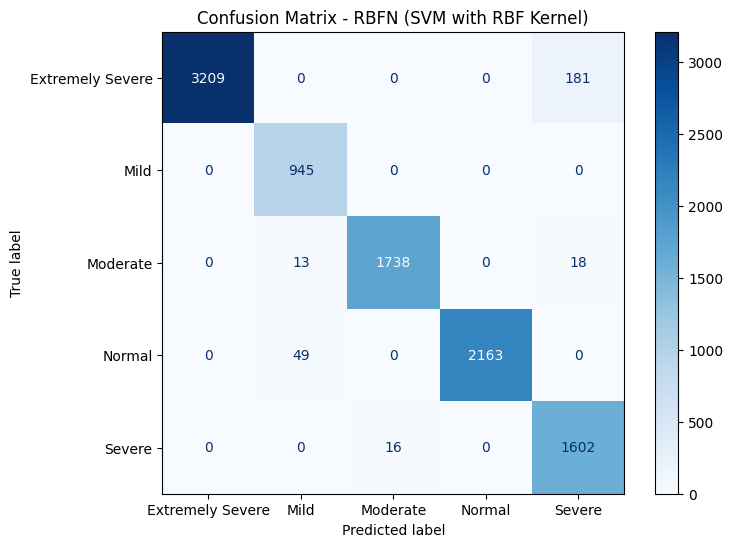

In [ ]:
# Import necessary libraries
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay, roc_auc_score, cohen_kappa_score
)
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import label_binarize

# Initialize and train SVM with RBF kernel (RBFN)
rbfn = SVC(kernel='rbf', C=1.0, gamma='scale', class_weight='balanced', probability=True, random_state=42)
rbfn.fit(X_train_pca, y_train_resampled)  # Train on SMOTE-applied PCA data

# Make predictions on PCA-transformed test data
y_pred_rbfn = rbfn.predict(X_test_pca)

# Compute evaluation metrics
Acc_rbfn = round(accuracy_score(y_test, y_pred_rbfn), 3)
f1_rbfn = round(f1_score(y_test, y_pred_rbfn, average='weighted'), 3)
recall_rbfn = round(recall_score(y_test, y_pred_rbfn, average='weighted'), 3)
precision_rbfn = round(precision_score(y_test, y_pred_rbfn, average='weighted'), 3)

# Compute Error Rate
error_rbfn = round(1 - Acc_rbfn, 3)

# Compute Cohen's Kappa Score
kappa_rbfn = round(cohen_kappa_score(y_test, y_pred_rbfn), 3)

# Compute ROC-AUC Score (for multi-class, using One-vs-Rest approach)
y_test_bin = label_binarize(y_test, classes=np.unique(y_test))
y_pred_prob = rbfn.predict_proba(X_test_pca)
roc_auc_rbfn = round(roc_auc_score(y_test_bin, y_pred_prob, average='weighted', multi_class='ovr'), 3)

# Print evaluation results
print("\U0001F535 Radial Basis Function Network (RBFN) Performance Metrics \U0001F535")
print(f"Accuracy: {Acc_rbfn}")
print(f"F1 Score: {f1_rbfn}")
print(f"Recall Score: {recall_rbfn}")
print(f"Precision Score: {precision_rbfn}")
print(f"Error Rate: {error_rbfn}")
print(f"Cohen's Kappa Score: {kappa_rbfn}")
print(f"ROC Area (AUC-ROC): {roc_auc_rbfn}")

# Perform Cross-Validation
cv_score_rbfn = round(np.mean(cross_val_score(rbfn, X_train_pca, y_train_resampled, cv=5)), 3)
print(f"Cross Validation Score: {cv_score_rbfn}")

# Print classification report
print("\n\U0001F535 Classification Report \U0001F535")
print(classification_report(y_test, y_pred_rbfn, digits=4))

# Confusion Matrix Visualization
cm_rbfn = confusion_matrix(y_test, y_pred_rbfn)
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_rbfn, display_labels=rbfn.classes_)
disp.plot(cmap="Blues", ax=ax)
plt.title("Confusion Matrix - RBFN (SVM with RBF Kernel)")
plt.show()


In [ ]:
# Import Required Libraries
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, cohen_kappa_score
import numpy as np

# Encode the labels
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train_resampled)
y_test_encoded = label_encoder.transform(y_test)

# One-Hot Encoding for ROC-AUC calculation
one_hot_encoder = OneHotEncoder(sparse_output=False)
y_test_onehot = one_hot_encoder.fit_transform(y_test_encoded.reshape(-1, 1))

# Define the ANN Model
model = Sequential([
    keras.layers.Input(shape=(X_train_pca.shape[1],)),  # Explicit Input layer
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dense(len(np.unique(y_train_encoded)), activation='softmax')  # Output Layer
])

# Compile the Model
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Implement Early Stopping (if validation loss increases for 5 epochs, stop training)
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1)

# Train the Model (Removed Cross-Validation)
history = model.fit(X_train_pca, y_train_encoded, epochs=50, batch_size=32,
                    validation_data=(X_test_pca, y_test_encoded), callbacks=[early_stopping])

# Predictions
y_pred_ann = np.argmax(model.predict(X_test_pca), axis=1)

# Evaluation Metrics
accuracy_ann = round(accuracy_score(y_test_encoded, y_pred_ann), 3)
error_rate_ann = round(1 - accuracy_ann, 3)
kappa_ann = round(cohen_kappa_score(y_test_encoded, y_pred_ann), 3)
auc_roc_ann = round(roc_auc_score(y_test_onehot, model.predict(X_test_pca)), 3)  # Multi-class ROC-AUC



# Print Performance Metrics
print("\n🔹 ANN Performance Metrics 🔹")
print(f"Accuracy: {accuracy_ann}")
print(f"Error Rate: {error_rate_ann}")
print(f"Cohen's Kappa Score: {kappa_ann}")
print(f"ROC Area (AUC-ROC): {auc_roc_ann}")

# Classification Report
print("\n🔹 ANN Classification Report 🔹")
report_dict = classification_report(y_test_encoded, y_pred_ann, output_dict=True, digits=4)
print(report_dict)
precision_ann = round(report_dict['macro avg']['precision'], 3)
recall_ann = round(report_dict['macro avg']['recall'], 3)
f1_score_ann = round(report_dict['macro avg']['f1-score'], 3)

Epoch 1/50
1362/1362 ━━━━━━━━━━━━━━━━━━━━ 13s 6ms/step - accuracy: 0.7792 - loss: 0.5323 - val_accuracy: 0.9129 - val_loss: 0.1927
Epoch 2/50
1362/1362 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9598 - loss: 0.1027 - val_accuracy: 0.9533 - val_loss: 0.1197
Epoch 3/50
1362/1362 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9772 - loss: 0.0633 - val_accuracy: 0.9666 - val_loss: 0.0933
Epoch 4/50
1362/1362 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9826 - loss: 0.0472 - val_accuracy: 0.9696 - val_loss: 0.0736
Epoch 5/50
1362/1362 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9887 - loss: 0.0332 - val_accuracy: 0.9643 - val_loss: 0.0980
Epoch 6/50
1362/1362 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9900 - loss: 0.0296 - val_accuracy: 0.9721 - val_loss: 0.0654
Epoch 7/50
1362/1362 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9920 - loss: 0.0229 - val_accuracy: 0.9770 - val_loss: 0.0765
Epoch 8/50
1362/1362 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9933 - loss: 0.0192 -

In [ ]:
train_acc = history.history['accuracy'][-1]
val_acc = history.history['val_accuracy'][-1]
print(f"Training Accuracy: {train_acc:.4f}")
print(f"Validation Accuracy: {val_acc:.4f}")


Training Accuracy: 0.9966
Validation Accuracy: 0.9836


In [ ]:
Stress=pd.merge(stress,new_data,how='left',left_index=True,right_index=True)
Stress.head()

,Q1A,Q6A,Q8A,Q11A,Q12A,Q14A,Q18A,Q22A,Q27A,Q29A,Q32A,Q33A,Q35A,Q39A,Total_Count,Extraverted-enthusiastic,Critical-quarrelsome,Dependable-self_disciplined,Anxious-easily upset,Open to new experiences-complex,Reserved-quiet,Sympathetic-warm,Disorganized-careless,Calm-emotionally_stable,Conventional-uncreative,education,urban,gender,age,religion,race,married,familysize
0,3,3,3,3,3,3,3,3,3,3,3,1,3,3,40,1,5,7,7,7,7,7,5,1,1,2,3,2,16,12,10,1,2
1,3,3,3,1,1,3,1,2,2,2,2,2,1,1,27,6,5,4,7,5,4,7,7,1,5,2,3,2,16,7,70,1,4
2,2,2,2,1,0,0,1,2,1,1,2,0,2,1,17,2,5,2,2,5,6,5,5,3,2,2,3,2,17,4,60,1,3
3,1,2,1,1,0,3,0,0,3,2,0,1,0,2,16,1,1,7,4,6,4,6,1,6,1,1,3,2,13,4,70,1,5
4,1,1,3,1,3,3,3,2,1,1,3,3,2,2,29,2,5,3,6,5,5,5,6,3,3,3,2,2,19,10,10,1,4


In [ ]:
def condition(x):
    if x<=14:
        return 'Normal'
    if  15<=x<=18:
        return 'Mild'
    if 19<=x<=25:
        return 'Moderate'
    if 26<=x<=33:
        return 'Severe'
    if x>=34:
        return 'Extremely Severe'

Stress['Condition']=Stress['Total_Count'].apply(condition)

Stress.head()

,Q1A,Q6A,Q8A,Q11A,Q12A,Q14A,Q18A,Q22A,Q27A,Q29A,Q32A,Q33A,Q35A,Q39A,Total_Count,Extraverted-enthusiastic,Critical-quarrelsome,Dependable-self_disciplined,Anxious-easily upset,Open to new experiences-complex,Reserved-quiet,Sympathetic-warm,Disorganized-careless,Calm-emotionally_stable,Conventional-uncreative,education,urban,gender,age,religion,race,married,familysize,Condition
0,3,3,3,3,3,3,3,3,3,3,3,1,3,3,40,1,5,7,7,7,7,7,5,1,1,2,3,2,16,12,10,1,2,Extremely Severe
1,3,3,3,1,1,3,1,2,2,2,2,2,1,1,27,6,5,4,7,5,4,7,7,1,5,2,3,2,16,7,70,1,4,Severe
2,2,2,2,1,0,0,1,2,1,1,2,0,2,1,17,2,5,2,2,5,6,5,5,3,2,2,3,2,17,4,60,1,3,Mild
3,1,2,1,1,0,3,0,0,3,2,0,1,0,2,16,1,1,7,4,6,4,6,1,6,1,1,3,2,13,4,70,1,5,Mild
4,1,1,3,1,3,3,3,2,1,1,3,3,2,2,29,2,5,3,6,5,5,5,6,3,3,3,2,2,19,10,10,1,4,Severe


Text(0.5, 1.0, 'People Condition for Stress Level')

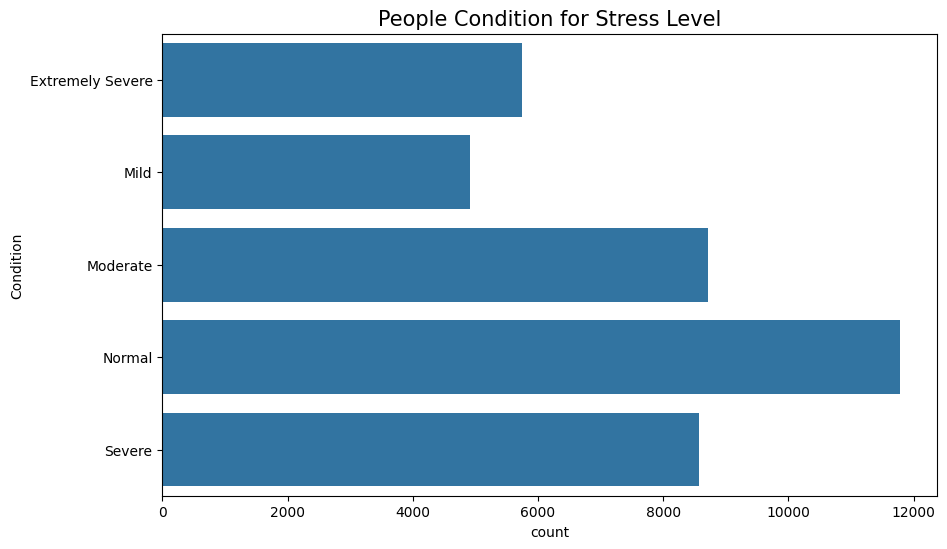

In [ ]:
plt.figure(figsize=(10,6))
sns.countplot(Stress.sort_values('Condition').Condition)
plt.title('People Condition for Stress Level',fontsize=15)

In [ ]:
Str=Stress.copy()
def condition(x):
    if x<=9:
        return 0
    if  10<=x<=13:
        return 1
    if 14<=x<=20:
        return 2
    if 21<=x<=27:
        return 3
    if x>28:
        return 4

def cond(x):
    if x<=10:
        return 0
    if  10<=x<=16:
        return 1
    if 17<=x<=21:
        return 2
    if 21<=x<=35:
        return 3
    if 36<=x<=48:
        return 4
    if x>=49:
        return 5
Str['Condition']=Str['Total_Count'].apply(condition)
Str['Age_Groups']=Str['age'].apply(cond)
Str=Str.drop(columns=['age','Total_Count'])
Str.head()

,Q1A,Q6A,Q8A,Q11A,Q12A,Q14A,Q18A,Q22A,Q27A,Q29A,Q32A,Q33A,Q35A,Q39A,Extraverted-enthusiastic,Critical-quarrelsome,Dependable-self_disciplined,Anxious-easily upset,Open to new experiences-complex,Reserved-quiet,Sympathetic-warm,Disorganized-careless,Calm-emotionally_stable,Conventional-uncreative,education,urban,gender,religion,race,married,familysize,Condition,Age_Groups
0,3,3,3,3,3,3,3,3,3,3,3,1,3,3,1,5,7,7,7,7,7,5,1,1,2,3,2,12,10,1,2,4.0,1
1,3,3,3,1,1,3,1,2,2,2,2,2,1,1,6,5,4,7,5,4,7,7,1,5,2,3,2,7,70,1,4,3.0,1
2,2,2,2,1,0,0,1,2,1,1,2,0,2,1,2,5,2,2,5,6,5,5,3,2,2,3,2,4,60,1,3,2.0,2
3,1,2,1,1,0,3,0,0,3,2,0,1,0,2,1,1,7,4,6,4,6,1,6,1,1,3,2,4,70,1,5,2.0,1
4,1,1,3,1,3,3,3,2,1,1,3,3,2,2,2,5,3,6,5,5,5,6,3,3,3,2,2,10,10,1,4,4.0,2


In [ ]:
# Import required libraries
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay, accuracy_score, precision_score,
    recall_score, f1_score, classification_report
)
import numpy as np
import matplotlib.pyplot as plt
from imblearn.over_sampling import SMOTE
from sklearn.decomposition import PCA
from sklearn.preprocessing import MinMaxScaler
from sklearn.utils import shuffle
from sklearn.model_selection import train_test_split

# Shuffle the dataset
Stress = shuffle(Stress, random_state=42)

# Splitting features and target
X = Stress.iloc[:, :-1]  # Features
y = Stress.iloc[:, -1]    # Target

# Splitting into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=0
)

# Apply Min-Max Scaling
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#Apply SMOTE before PCA
from imblearn.combine import SMOTEENN
smote_enn = SMOTEENN(random_state=42)
X_train_resampled, y_train_resampled = smote_enn.fit_resample(X_train_scaled, y_train)

#Apply PCA after SMOTE
pca = PCA(n_components=0.95)  # Retain 95% variance
X_train_pca = pca.fit_transform(X_train_resampled)
X_test_pca = pca.transform(X_test_scaled)

from collections import Counter
print("Before SMOTE:", Counter(y_train))
print("After SMOTE:", Counter(y_train_resampled))

print("Explained Variance Ratio:", np.sum(pca.explained_variance_ratio_))

print("Original feature count:", X_train.shape[1])
print("Reduced feature count after PCA:", X_train_pca.shape[1])



Before SMOTE: Counter({'Normal': 8840, 'Moderate': 6538, 'Severe': 6424, 'Extremely Severe': 4308, 'Mild': 3689})
After SMOTE: Counter({'Extremely Severe': 8301, 'Mild': 7616, 'Normal': 6319, 'Severe': 5697, 'Moderate': 5047})
Explained Variance Ratio: 0.955885749382152
Original feature count: 33
Reduced feature count after PCA: 26


Best Parameters: {'C': 10, 'max_iter': 100, 'solver': 'lbfgs'}
Cross-Validation Scores: [0.99848393 0.99818072 0.99848393 0.99833232 0.99833232]
Mean CV Score: 0.9983626440266828
Accuracy: 0.98
F1 Score: 0.98
Recall Score: 0.98
Precision Score: 0.982
Error Rate: 0.02
Cohen's Kappa Score: 0.974
ROC Area (AUC-ROC): 1.0
                  precision    recall  f1-score   support

Extremely Severe     0.9993    1.0000    0.9997      1436
            Mild     0.8635    0.9984    0.9260      1229
        Moderate     0.9986    0.9963    0.9975      2180
          Normal     0.9993    0.9369    0.9671      2947
          Severe     1.0000    0.9981    0.9991      2142

        accuracy                         0.9799      9934
       macro avg     0.9721    0.9859    0.9779      9934
    weighted avg     0.9825    0.9799    0.9803      9934



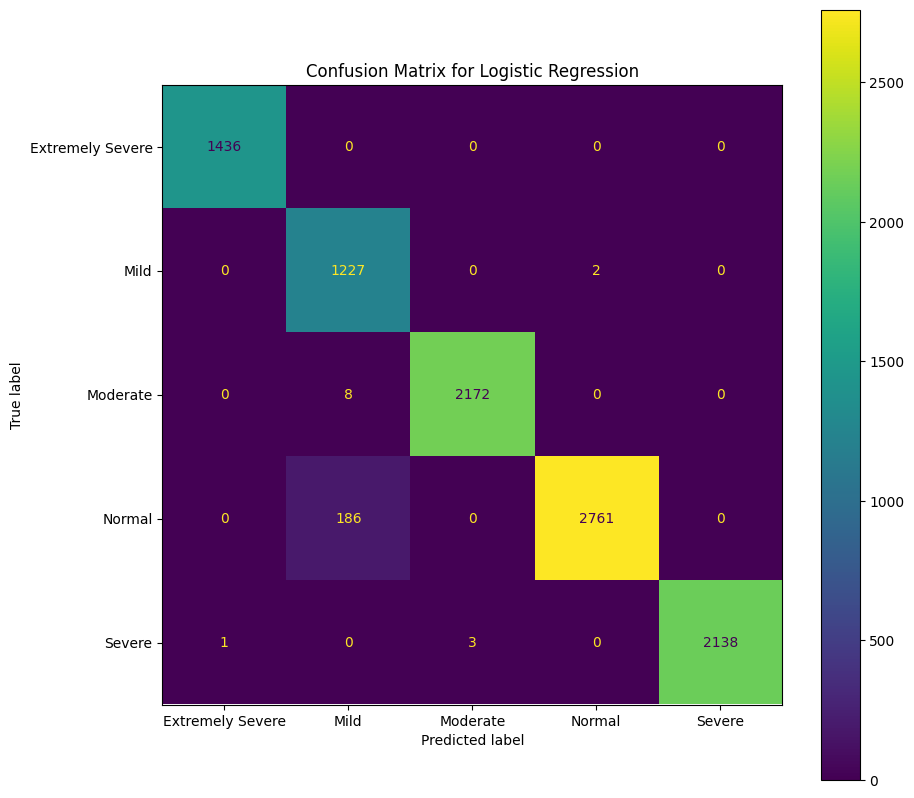

In [ ]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import cohen_kappa_score, roc_auc_score
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

#Define hyperparameter grid for GridSearchCV

param_grid = {
    'C': [0.001, 0.01, 10],  # Regularization strength
    'max_iter': [100,200,500,1000],  # Maximum iterations (as per IEEE paper)
    'solver': ['lbfgs'],  # LBFGS solver (as per IEEE paper)
}
#Initialize Logistic Regression
log_reg = LogisticRegression(random_state=42, class_weight='balanced',penalty="l2")

#Perform GridSearchCV with cross-validation
grid_search = GridSearchCV(
    estimator=log_reg,
    param_grid=param_grid,
    cv=skf,  # 5-fold cross-validation (as per IEEE paper)
    scoring='accuracy',  # Optimize for accuracy
    n_jobs=-1  # Use all CPU cores
)

#Fit the model with correctly preprocessed data
grid_search.fit(X_train_pca, y_train_resampled)

#Best parameters and model
print("Best Parameters:", grid_search.best_params_)
best_log_reg = grid_search.best_estimator_

# Cross-validation score on the training set
cv_scores = cross_val_score(best_log_reg, X_train_pca, y_train_resampled, cv=5)
print("Cross-Validation Scores:", cv_scores)
print("Mean CV Score:", np.mean(cv_scores))

# Make predictions on the test set
y_pred = best_log_reg.predict(X_test_pca)

#Calculate evaluation metrics
Acc_lr = round(accuracy_score(y_test, y_pred), 3)
f1_lr = round(f1_score(y_test, y_pred, average='weighted'), 3)
recall_lr = round(recall_score(y_test, y_pred, average='weighted'), 3)
precision_lr = round(precision_score(y_test, y_pred, average='weighted'), 3)

#Print evaluation metrics
print('Accuracy:', Acc_lr)
print('F1 Score:', f1_lr)
print('Recall Score:', recall_lr)
print('Precision Score:', precision_lr)

# Compute Error Rate
error_rate = round(1 - Acc_lr, 3)
print("Error Rate:", error_rate)

# Compute Cohen's Kappa Score
kappa = round(cohen_kappa_score(y_test, y_pred), 3)
print("Cohen's Kappa Score:", kappa)

# Compute ROC Area (AUC-ROC)

if len(set(y_test)) == 2:  # Binary classification
    y_pred_proba = best_log_reg.predict_proba(X_test_pca)[:, 1]
    roc_auc = round(roc_auc_score(y_test, y_pred_proba), 3)
else:  # Multiclass classification
    y_pred_proba = best_log_reg.predict_proba(X_test_pca)
    roc_auc = round(roc_auc_score(y_test, y_pred_proba, multi_class="ovr"), 3)

print("ROC Area (AUC-ROC):", roc_auc)


#Classification report
classification = classification_report(y_test, y_pred, digits=4)
print(classification)

#Confusion matrix and display
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(10, 10))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=best_log_reg.classes_)
disp.plot(cmap='viridis', ax=ax)
plt.title("Confusion Matrix for Logistic Regression")
plt.show()


🔹 Gaussian Naïve Bayes Performance Metrics 🔹
Accuracy: 0.9
F1 Score: 0.903
Recall Score: 0.9
Precision Score: 0.911
Cohen's Kappa Score: 0.873
ROC Area (AUC-ROC): 0.992
Error Rate: 0.1
Cross Validation Score: 0.961

🔹 Classification Report 🔹
                  precision    recall  f1-score   support

Extremely Severe     0.9311    0.9227    0.9269      1436
            Mild     0.6905    0.9186    0.7884      1229
        Moderate     0.9187    0.8862    0.9022      2180
          Normal     0.9890    0.8853    0.9343      2947
          Severe     0.9105    0.9076    0.9090      2142

        accuracy                         0.8998      9934
       macro avg     0.8880    0.9041    0.8922      9934
    weighted avg     0.9114    0.8998    0.9027      9934



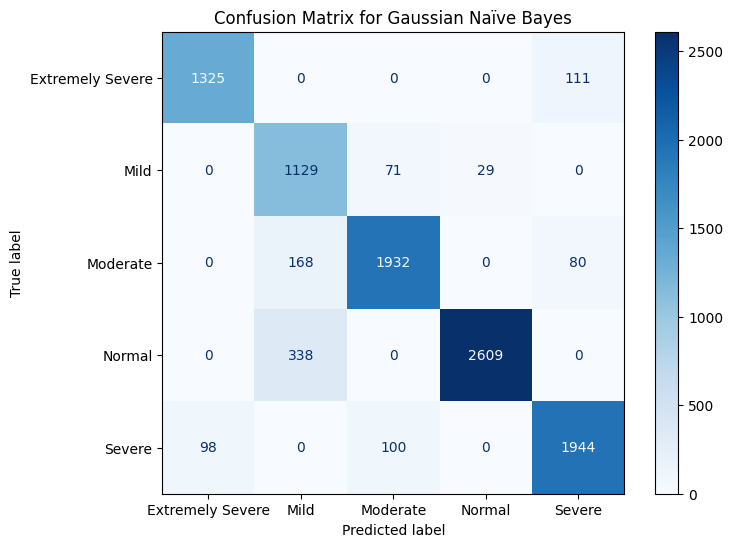

In [ ]:
# Import necessary libraries
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay, accuracy_score, precision_score,
    recall_score, f1_score, classification_report
)
from sklearn.model_selection import cross_val_score
from sklearn.metrics import cohen_kappa_score, roc_auc_score
import numpy as np
import matplotlib.pyplot as plt

#Initialize and train Gaussian Naïve Bayes model on PCA-transformed & SMOTE-applied data
gnb = GaussianNB()
gnb.fit(X_train_pca, y_train_resampled)

#Predictions on PCA-transformed test data
y_pred_gnb = gnb.predict(X_test_pca)

#Calculate evaluation metrics
Acc_gnb = round(accuracy_score(y_test, y_pred_gnb), 3)
f1_gnb = round(f1_score(y_test, y_pred_gnb, average='weighted'), 3)
recall_gnb = round(recall_score(y_test, y_pred_gnb, average='weighted'), 3)
precision_gnb = round(precision_score(y_test, y_pred_gnb, average='weighted'), 3)
error_rate_gnb = round(1 - Acc_gnb, 3)  # Error rate = 1 - Accuracy
kappa_gnb = round(cohen_kappa_score(y_test, y_pred_gnb), 3)  # Cohen’s Kappa

# Compute ROC-AUC (For multiclass classification, use `ovr` strategy)
roc_auc_gnb = round(roc_auc_score(y_test, gnb.predict_proba(X_test_pca), multi_class='ovr'), 3)

#Print evaluation results
print("🔹 Gaussian Naïve Bayes Performance Metrics 🔹")
print(f"Accuracy: {Acc_gnb}")
print(f"F1 Score: {f1_gnb}")
print(f"Recall Score: {recall_gnb}")
print(f"Precision Score: {precision_gnb}")
print(f"Cohen's Kappa Score: {kappa_gnb}")
print(f"ROC Area (AUC-ROC): {roc_auc_gnb}")
print(f"Error Rate: {error_rate_gnb}")

#Perform Cross-Validation on PCA-transformed data
cv_score_gnb = round(np.mean(cross_val_score(gnb, X_train_pca, y_train_resampled, cv=6)), 3)
print(f"Cross Validation Score: {cv_score_gnb}")

#Print classification report
print("\n🔹 Classification Report 🔹")
print(classification_report(y_test, y_pred_gnb, digits=4))

error_rate_gnb = round(1 - Acc_gnb, 3)  # Error rate = 1 - Accuracy
kappa_gnb = round(cohen_kappa_score(y_test, y_pred_gnb), 3)  # Cohen’s Kappa

# Compute ROC-AUC (For multiclass classification, use `ovr` strategy)
roc_auc_gnb = round(roc_auc_score(y_test, gnb.predict_proba(X_test_pca), multi_class='ovr'), 3)

#Confusion Matrix Visualization
cm_gnb = confusion_matrix(y_test, y_pred_gnb)
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_gnb, display_labels=gnb.classes_)
disp.plot(cmap="Blues", ax=ax)
plt.title("Confusion Matrix for Gaussian Naïve Bayes")
plt.show()


/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_search.py:1108: UserWarning: One or more of the test scores are non-finite: [       nan 0.96173396        nan 0.95894754        nan 0.95195614
 0.96570615 0.97339531 0.94169639 0.96787498 0.94079969 0.95643353]
  warnings.warn(



🔹 K-Nearest Neighbors Performance Metrics 🔹
Best Parameters: {'metric': 'euclidean', 'n_neighbors': 5, 'weights': 'distance'}
Accuracy: 0.774
F1 Score: 0.784
Recall Score: 0.774
Precision Score: 0.833
Error Rate: 0.226
ROC Area (AUC-ROC): 0.948
Cohen's Kappa Score: 0.718
Cross Validation Score: 0.973

🔹 Classification Report 🔹
                  precision    recall  f1-score   support

Extremely Severe     0.8129    0.9680    0.8837      1436
            Mild     0.4581    0.9211    0.6119      1229
        Moderate     0.8320    0.6225    0.7121      2180
          Normal     0.9900    0.7414    0.8479      2947
          Severe     0.8486    0.7586    0.8011      2142

        accuracy                         0.7740      9934
       macro avg     0.7883    0.8023    0.7713      9934
    weighted avg     0.8334    0.7740    0.7840      9934



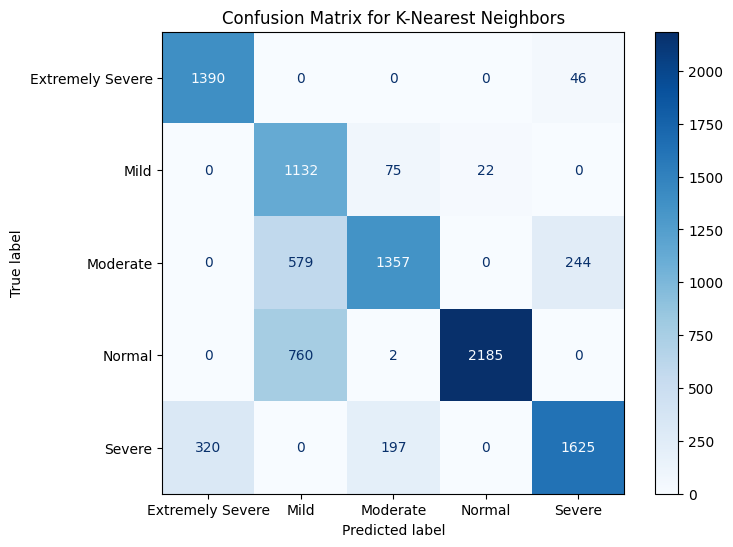

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay, roc_auc_score, cohen_kappa_score
)
import numpy as np
import matplotlib.pyplot as plt

# Define hyperparameter grid for KNN
param_grid = {
    'n_neighbors': [5,10,15],  # Number of neighbors
    'weights': ['uniform', 'distance'],  # Voting strategy
    'metric': ['manhattan','euclidean']  # Distance metric
}

# Initialize KNN classifier
knn = KNeighborsClassifier()

# Perform GridSearchCV
grid_search_knn = GridSearchCV(
    estimator=knn,
    param_grid=param_grid,
    cv=5,  # 5-fold cross-validation
    scoring='f1_weighted',  # Optimize for F1-score
    n_jobs=-1
)

# Train the KNN model using PCA-transformed and SMOTE-resampled data
grid_search_knn.fit(X_train_pca, y_train_resampled)

# Get the best model
best_knn = grid_search_knn.best_estimator_

# Predict on the test set
y_pred_knn = best_knn.predict(X_test_pca)

# Calculate evaluation metrics
Acc_knn = round(accuracy_score(y_test, y_pred_knn), 3)
f1_knn = round(f1_score(y_test, y_pred_knn, average='weighted'), 3)
recall_knn = round(recall_score(y_test, y_pred_knn, average='weighted'), 3)
precision_knn = round(precision_score(y_test, y_pred_knn, average='weighted'), 3)
error_rate_knn = round(1 - Acc_knn, 3)  # Error Rate

# Compute ROC-AUC (requires probability estimates)
y_pred_prob_knn = best_knn.predict_proba(X_test_pca)
roc_auc_knn = round(roc_auc_score(y_test, y_pred_prob_knn, multi_class='ovr'), 3)

# Compute Cohen's Kappa Score
kappa_knn = round(cohen_kappa_score(y_test, y_pred_knn), 3)

# Print evaluation metrics
print("\n🔹 K-Nearest Neighbors Performance Metrics 🔹")
print(f"Best Parameters: {grid_search_knn.best_params_}")
print(f"Accuracy: {Acc_knn}")
print(f"F1 Score: {f1_knn}")
print(f"Recall Score: {recall_knn}")
print(f"Precision Score: {precision_knn}")
print(f"Error Rate: {error_rate_knn}")
print(f"ROC Area (AUC-ROC): {roc_auc_knn}")
print(f"Cohen's Kappa Score: {kappa_knn}")

# Cross-validation Score
cv_score_knn = round(np.mean(cross_val_score(best_knn, X_train_pca, y_train_resampled, cv=5)), 3)
print(f"Cross Validation Score: {cv_score_knn}")

# Classification Report
print("\n🔹 Classification Report 🔹")
print(classification_report(y_test, y_pred_knn, digits=4))

# Confusion Matrix Visualization
cm_knn = confusion_matrix(y_test, y_pred_knn)
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_knn, display_labels=best_knn.classes_)
disp.plot(cmap="Blues", ax=ax)
plt.title("Confusion Matrix for K-Nearest Neighbors")
plt.show()


Training Kappa Score (RBFN): 0.9969
🔹 Radial Basis Function Network (RBFN) Performance Metrics 🔹
Accuracy: 0.947
F1 Score: 0.949
Recall Score: 0.947
Precision Score: 0.957
Cross Validation Score: 0.995

🔹 Classification Report 🔹
                  precision    recall  f1-score   support

Extremely Severe     0.9656    0.9965    0.9808      1436
            Mild     0.7497    0.9943    0.8548      1229
        Moderate     0.9773    0.9482    0.9625      2180
          Normal     0.9996    0.8955    0.9447      2947
          Severe     0.9913    0.9566    0.9736      2142

        accuracy                         0.9471      9934
       macro avg     0.9367    0.9582    0.9433      9934
    weighted avg     0.9571    0.9471    0.9489      9934

Error Rate: 0.053
Cohen's Kappa Score: 0.933
ROC Area (AUC-ROC): 1.0


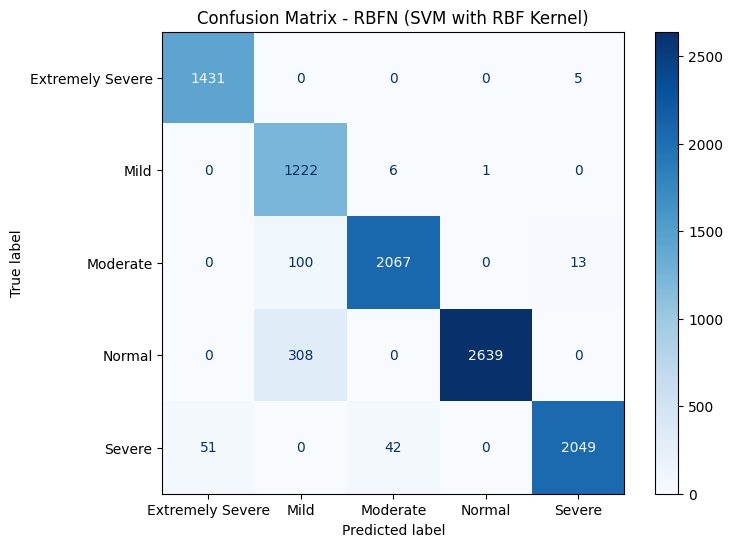

In [ ]:
# Import necessary libraries
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_val_score

#Initialize and train SVM with RBF kernel (RBFN)

rbfn = SVC(kernel='rbf', C=0.5, gamma='scale', class_weight='balanced',probability=True, random_state=42)
rbfn.fit(X_train_pca, y_train_resampled)  # Train on SMOTE-applied PCA data

#Make predictions on PCA-transformed test data
y_pred_rbfn = rbfn.predict(X_test_pca)

y_train_pred_rbfn = rbfn.predict(X_train_pca)
# Compute and print Kappa score
kappa_train_rbfn = cohen_kappa_score(y_train_resampled, y_train_pred_rbfn)
print(f"Training Kappa Score (RBFN): {kappa_train_rbfn:.4f}")

#Compute evaluation metrics
Acc_rbfn = round(accuracy_score(y_test, y_pred_rbfn), 3)
f1_rbfn = round(f1_score(y_test, y_pred_rbfn, average='weighted'), 3)
recall_rbfn = round(recall_score(y_test, y_pred_rbfn, average='weighted'), 3)
precision_rbfn = round(precision_score(y_test, y_pred_rbfn, average='weighted'), 3)
error_rate_rbfn = round(1 - Acc_rbfn, 3)  # Error rate = 1 - Accuracy
kappa_rbfn = round(cohen_kappa_score(y_test, y_pred_rbfn), 3)  # Cohen’s Kappa Score

# Compute ROC-AUC (For multiclass classification, use `ovr` strategy)
roc_auc_rbfn = round(roc_auc_score(y_test, rbfn.predict_proba(X_test_pca), multi_class='ovr'), 3)


#Print evaluation results
print("🔹 Radial Basis Function Network (RBFN) Performance Metrics 🔹")
print(f"Accuracy: {Acc_rbfn}")
print(f"F1 Score: {f1_rbfn}")
print(f"Recall Score: {recall_rbfn}")
print(f"Precision Score: {precision_rbfn}")

#Perform Cross-Validation
cv_score_rbfn = round(np.mean(cross_val_score(rbfn, X_train_pca, y_train_resampled, cv=5)), 3)
print(f"Cross Validation Score: {cv_score_rbfn}")

#Print classification report
print("\n🔹 Classification Report 🔹")
print(classification_report(y_test, y_pred_rbfn, digits=4))
print(f"Error Rate: {error_rate_rbfn}")
print(f"Cohen's Kappa Score: {kappa_rbfn}")
print(f"ROC Area (AUC-ROC): {roc_auc_rbfn}")

#Confusion Matrix Visualization
cm_rbfn = confusion_matrix(y_test, y_pred_rbfn)
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_rbfn, display_labels=rbfn.classes_)
disp.plot(cmap="Blues", ax=ax)
plt.title("Confusion Matrix - RBFN (SVM with RBF Kernel)")
plt.show()


🔹 Best Parameters: {'criterion': 'entropy', 'max_depth': 10, 'min_samples_leaf': 5, 'min_samples_split': 15}
Best ccp_alpha: 7.596687243370126e-05

🔹 Decision Tree Performance Metrics 🔹
Accuracy: 0.932
F1 Score: 0.933
Recall Score: 0.932
Precision Score: 0.938
Error Rate: 0.068
Cohen's Kappa Score: 0.913
ROC Area (AUC-ROC): 0.975
Cross Validation Score: 0.982

🔹 Classification Report 🔹
                  precision    recall  f1-score   support

Extremely Severe     0.9416    0.9763    0.9586      1436
            Mild     0.7693    0.9552    0.8523      1229
        Moderate     0.9377    0.9110    0.9242      2180
          Normal     0.9942    0.9274    0.9596      2947
          Severe     0.9561    0.9160    0.9356      2142

        accuracy                         0.9319      9934
       macro avg     0.9198    0.9372    0.9261      9934
    weighted avg     0.9382    0.9319    0.9332      9934



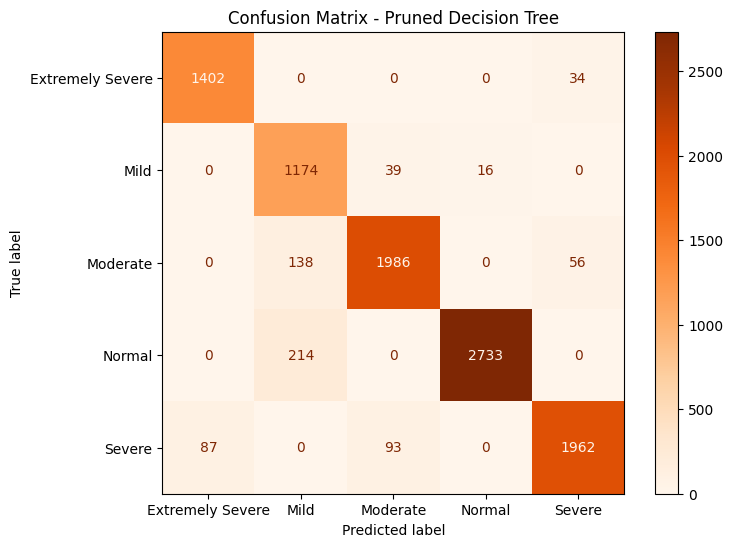

Training Accuracy: 0.9940
Test Accuracy: 0.9319


In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)
import numpy as np
import matplotlib.pyplot as plt

# Initialize Decision Tree Classifier
dt = DecisionTreeClassifier(random_state=42)

#Expanded Hyperparameter Grid to Reduce Overfitting
param_grid = {
    "criterion": ["gini", "entropy"],
    "max_depth": [6, 8, 10],  # Reduced depth to avoid overfitting
    "min_samples_split": [5, 10, 15],  # Encourage generalization
    "min_samples_leaf": [5, 10]  # Force larger leaf sizes
}

#Perform Grid Search with Cross-Validation
grid_search = GridSearchCV(
    estimator=dt,
    param_grid=param_grid,
    cv=5,
    scoring="f1_weighted",
    n_jobs=-1
)

grid_search.fit(X_train_pca, y_train_resampled)

#Best Model Selection
best_dt = grid_search.best_estimator_
print(f"🔹 Best Parameters: {grid_search.best_params_}")

#Cost Complexity Pruning
path = best_dt.cost_complexity_pruning_path(X_train_pca, y_train_resampled)
ccp_alphas = path.ccp_alphas[:-1]  # Exclude last max alpha (pruning all nodes)

pruned_models = [DecisionTreeClassifier(ccp_alpha=alpha).fit(X_train_pca, y_train_resampled) for alpha in ccp_alphas]
val_scores = [accuracy_score(y_test, model.predict(X_test_pca)) for model in pruned_models]

best_alpha = ccp_alphas[np.argmax(val_scores)]
print(f"Best ccp_alpha: {best_alpha}")

#Train Final Model with Best Pruning Level
pruned_dt = DecisionTreeClassifier(ccp_alpha=best_alpha, **grid_search.best_params_)
pruned_dt.fit(X_train_pca, y_train_resampled)

#Make Predictions
y_pred_dt = pruned_dt.predict(X_test_pca)

#Evaluation Metrics
Acc_dt = round(accuracy_score(y_test, y_pred_dt), 3)
f1_dt = round(f1_score(y_test, y_pred_dt, average="weighted"), 3)
recall_dt = round(recall_score(y_test, y_pred_dt, average="weighted"), 3)
precision_dt = round(precision_score(y_test, y_pred_dt, average="weighted"), 3)
error_rate_dt = round(1 - Acc_dt, 3)  # Error rate = 1 - Accuracy
kappa_dt = round(cohen_kappa_score(y_test, y_pred_dt), 3)  # Cohen’s Kappa Score

# Compute ROC-AUC (For multiclass classification, use `ovr` strategy)
roc_auc_dt = round(roc_auc_score(y_test, pruned_dt.predict_proba(X_test_pca), multi_class='ovr'), 3)

# Print Performance Metrics
print("\n🔹 Decision Tree Performance Metrics 🔹")
print(f"Accuracy: {Acc_dt}")
print(f"F1 Score: {f1_dt}")
print(f"Recall Score: {recall_dt}")
print(f"Precision Score: {precision_dt}")
print(f"Error Rate: {error_rate_dt}")
print(f"Cohen's Kappa Score: {kappa_dt}")
print(f"ROC Area (AUC-ROC): {roc_auc_dt}")

#Cross-Validation Score
cv_score_dt = round(np.mean(cross_val_score(pruned_dt, X_train_pca, y_train_resampled, cv=6)), 3)
print(f"Cross Validation Score: {cv_score_dt}")

#Classification Report
print("\n🔹 Classification Report 🔹")
print(classification_report(y_test, y_pred_dt, digits=4))

#Confusion Matrix Visualization
cm_dt = confusion_matrix(y_test, y_pred_dt)
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_dt, display_labels=pruned_dt.classes_)
disp.plot(cmap="Oranges", ax=ax)
plt.title("Confusion Matrix - Pruned Decision Tree")
plt.show()

#Compare Train vs Test Accuracy
y_train_pred = pruned_dt.predict(X_train_pca)
train_acc = accuracy_score(y_train_resampled, y_train_pred)
test_acc = accuracy_score(y_test, y_pred_dt)
print(f"Training Accuracy: {train_acc:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 1 is smaller than n_iter=10. Running 1 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


🔹 Best Parameters: {'n_estimators': 150, 'min_samples_split': 7, 'min_samples_leaf': 5, 'max_features': 'sqrt', 'max_depth': 10, 'ccp_alpha': 0.02}

🔹 Random Forest Performance Metrics 🔹
Accuracy: 0.919
F1 Score: 0.921
Recall Score: 0.919
Precision Score: 0.927
Error Rate: 0.081
Cohen's Kappa Score: 0.897
ROC Area (AUC-ROC): 0.981
Cross Validation Score: 0.971

🔹 Classification Report 🔹
                  precision    recall  f1-score   support

Extremely Severe     0.9390    0.9749    0.9566      1436
            Mild     0.7351    0.9414    0.8255      1229
        Moderate     0.9214    0.8982    0.9096      2180
          Normal     0.9911    0.9091    0.9483      2947
          Severe     0.9476    0.9029    0.9247      2142

        accuracy                         0.9189      9934
       macro avg     0.9068    0.9253    0.9130      9934
    weighted avg     0.9272    0.9189    0.9207      9934



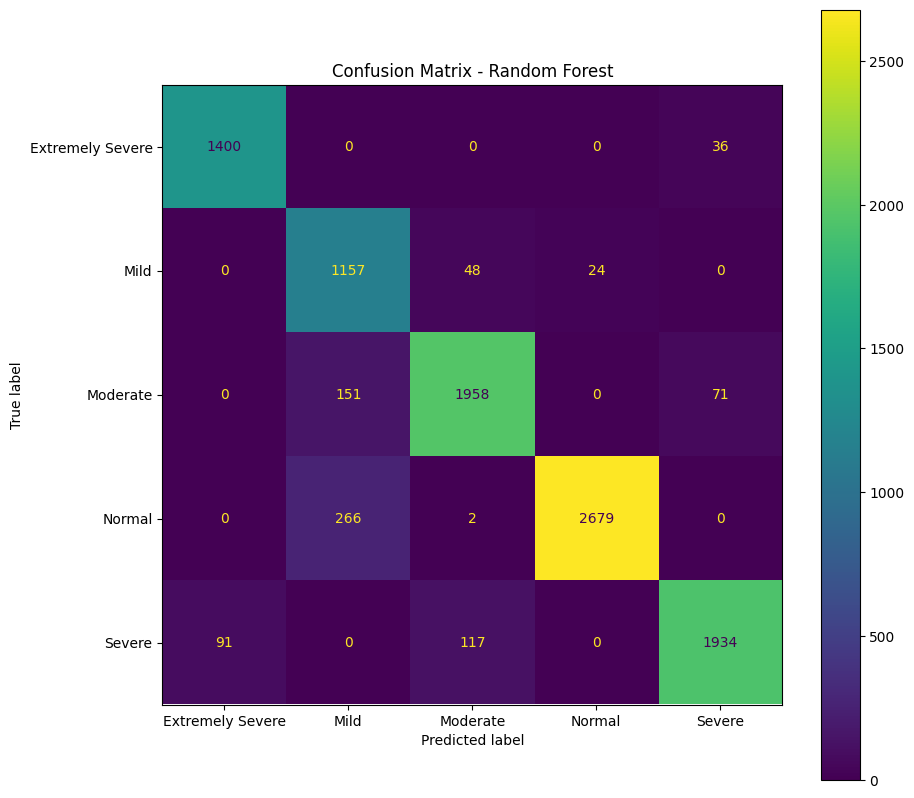

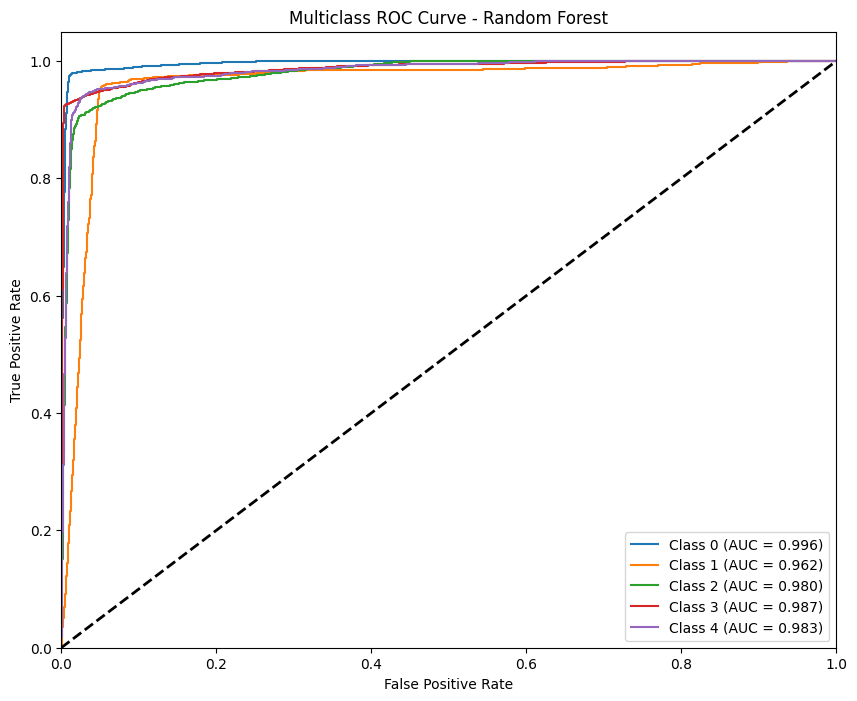

Training Accuracy: 0.9750


In [ ]:
#Import Required Libraries
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV, cross_val_score
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay, roc_auc_score, cohen_kappa_score
)
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

#Updated Hyperparameter Grid
param_dist = {
    "n_estimators": [150],
    "max_depth": [10],
    "min_samples_split": [7],
    "min_samples_leaf": [5],
    "max_features": ["sqrt"],
    "ccp_alpha": [0.02]
}

# Initialize RandomForest with Balanced Class Weights
RanFor = RandomForestClassifier(random_state=42, class_weight="balanced")

# Perform Randomized Search with CV
rand_search = RandomizedSearchCV(
    estimator=RanFor,
    param_distributions=param_dist,
    n_iter=10,
    cv=5,
    scoring='f1_weighted',
    n_jobs=-1,
    random_state=42
)

# Train with Resampled Data
rand_search.fit(X_train_pca, y_train_resampled)

# Use the Best Found Model
RanFor = rand_search.best_estimator_

# Predictions on Test Set
y_pred = RanFor.predict(X_test_pca)

# Compute Performance Metrics
Acc_ran = round(accuracy_score(y_test, y_pred), 3)
f1_ran = round(f1_score(y_test, y_pred, average='weighted'), 3)
recall_ran = round(recall_score(y_test, y_pred, average='weighted'), 3)
precision_ran = round(precision_score(y_test, y_pred, average='weighted'), 3)
error_rate = round(1 - Acc_ran, 3)
kappa_score = round(cohen_kappa_score(y_test, y_pred), 3)

#AUC-ROC Score Calculation
y_test_bin = label_binarize(y_test, classes=np.unique(y_test))  # Convert to One-vs-Rest (OvR)
y_pred_prob = RanFor.predict_proba(X_test_pca)  # Get probability estimates
auc_roc = round(roc_auc_score(y_test_bin, y_pred_prob, multi_class="ovr"), 3)

#Print Model Performance
print(f"🔹 Best Parameters: {rand_search.best_params_}")
print("\n🔹 Random Forest Performance Metrics 🔹")
print(f"Accuracy: {Acc_ran}")
print(f"F1 Score: {f1_ran}")
print(f"Recall Score: {recall_ran}")
print(f"Precision Score: {precision_ran}")
print(f"Error Rate: {error_rate}")
print(f"Cohen's Kappa Score: {kappa_score}")
print(f"ROC Area (AUC-ROC): {auc_roc}")

#Cross-Validation Score
cv_score_rf = round(np.mean(cross_val_score(RanFor, X_train_pca, y_train_resampled, cv=6)), 3)
print(f"Cross Validation Score: {cv_score_rf}")

#Classification Report
print("\n🔹 Classification Report 🔹")
print(classification_report(y_test, y_pred, digits=4))

# Confusion Matrix Visualization
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(10, 10))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=RanFor.classes_)
disp.plot(cmap='viridis', ax=ax)
plt.title("Confusion Matrix - Random Forest")
plt.show()

#ROC Curve for Multiclass Classification
fpr = dict()
tpr = dict()
roc_auc = dict()
n_classes = y_test_bin.shape[1]

plt.figure(figsize=(10, 8))
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_pred_prob[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])
    plt.plot(fpr[i], tpr[i], label=f'Class {i} (AUC = {roc_auc[i]:.3f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Multiclass ROC Curve - Random Forest")
plt.legend(loc="lower right")
plt.show()

#Training Accuracy Check (to compare with test accuracy)
train_acc = accuracy_score(y_train_resampled, RanFor.predict(X_train_pca))
print(f"Training Accuracy: {train_acc:.4f}")


In [ ]:
# Import Required Libraries
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, cohen_kappa_score
import numpy as np

# Encode the labels
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train_resampled)
y_test_encoded = label_encoder.transform(y_test)

# One-Hot Encoding for ROC-AUC calculation
one_hot_encoder = OneHotEncoder(sparse_output=False)
y_test_onehot = one_hot_encoder.fit_transform(y_test_encoded.reshape(-1, 1))

# Define the ANN Model
model = Sequential([
    keras.layers.Input(shape=(X_train_pca.shape[1],)),  # Explicit Input layer
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dense(len(np.unique(y_train_encoded)), activation='softmax')  # Output Layer
])

# Compile the Model
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Implement Early Stopping (if validation loss increases for 5 epochs, stop training)
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1)

# Train the Model (Removed Cross-Validation)
history = model.fit(X_train_pca, y_train_encoded, epochs=50, batch_size=32,
                    validation_data=(X_test_pca, y_test_encoded), callbacks=[early_stopping])

# Predictions
y_pred_ann = np.argmax(model.predict(X_test_pca), axis=1)

# Evaluation Metrics
accuracy_ann = round(accuracy_score(y_test_encoded, y_pred_ann), 3)
error_rate_ann = round(1 - accuracy_ann, 3)
kappa_ann = round(cohen_kappa_score(y_test_encoded, y_pred_ann), 3)
auc_roc_ann = round(roc_auc_score(y_test_onehot, model.predict(X_test_pca)), 3)  # Multi-class ROC-AUC

# Print Performance Metrics
print("\n🔹 ANN Performance Metrics 🔹")
print(f"Accuracy: {accuracy_ann}")
print(f"Error Rate: {error_rate_ann}")
print(f"Cohen's Kappa Score: {kappa_ann}")
print(f"ROC Area (AUC-ROC): {auc_roc_ann}")

# Classification Report
print("\n🔹 ANN Classification Report 🔹")
report_dict = classification_report(y_test_encoded, y_pred_ann, output_dict=True, digits=4)
print(report_dict)
precision_ann = round(report_dict['macro avg']['precision'], 3)
recall_ann = round(report_dict['macro avg']['recall'], 3)
f1_score_ann = round(report_dict['macro avg']['f1-score'], 3)


Epoch 1/50
1031/1031 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.7538 - loss: 0.5892 - val_accuracy: 0.9477 - val_loss: 0.1349
Epoch 2/50
1031/1031 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9514 - loss: 0.1238 - val_accuracy: 0.9507 - val_loss: 0.1176
Epoch 3/50
1031/1031 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9691 - loss: 0.0825 - val_accuracy: 0.9429 - val_loss: 0.1582
Epoch 4/50
1031/1031 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9724 - loss: 0.0739 - val_accuracy: 0.9263 - val_loss: 0.1689
Epoch 5/50
1031/1031 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9786 - loss: 0.0596 - val_accuracy: 0.9686 - val_loss: 0.0787
Epoch 6/50
1031/1031 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9810 - loss: 0.0512 - val_accuracy: 0.9687 - val_loss: 0.0765
Epoch 7/50
1031/1031 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9837 - loss: 0.0429 - val_accuracy: 0.9588 - val_loss: 0.1065
Epoch 8/50
1031/1031 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9866 - loss: 0.0355 -

In [ ]:
Anxiety=pd.merge(anxiety,new_data,how='left',left_index=True,right_index=True)
Anxiety.head()

,Q2A,Q4A,Q7A,Q9A,Q15A,Q19A,Q20A,Q23A,Q25A,Q28A,Q30A,Q36A,Q40A,Q41A,Total_Count,Extraverted-enthusiastic,Critical-quarrelsome,Dependable-self_disciplined,Anxious-easily upset,Open to new experiences-complex,Reserved-quiet,Sympathetic-warm,Disorganized-careless,Calm-emotionally_stable,Conventional-uncreative,education,urban,gender,age,religion,race,married,familysize
0,3,3,3,1,3,2,2,3,3,2,1,3,2,3,34,1,5,7,7,7,7,7,5,1,1,2,3,2,16,12,10,1,2
1,0,2,2,2,2,0,0,0,1,3,2,2,0,1,17,6,5,4,7,5,4,7,7,1,5,2,3,2,16,7,70,1,4
2,0,0,0,1,3,1,0,1,1,0,1,3,1,0,12,2,5,2,2,5,6,5,5,3,2,2,3,2,17,4,60,1,3
3,2,0,3,2,1,0,1,0,0,0,2,0,3,3,17,1,1,7,4,6,4,6,1,6,1,1,3,2,13,4,70,1,5
4,1,3,3,3,3,3,3,3,3,3,3,3,3,3,40,2,5,3,6,5,5,5,6,3,3,3,2,2,19,10,10,1,4


In [ ]:
def condition(x):
    if x<=7:
        return 'Normal'
    if  8<=x<=9:
        return 'Mild'
    if 10<=x<=14:
        return 'Moderate'
    if 15<=x<=19:
        return 'Severe'
    if x>19:
        return 'Extremely Severe'

Anxiety['Condition']=Anxiety['Total_Count'].apply(condition)
Anxiety.head()

,Q2A,Q4A,Q7A,Q9A,Q15A,Q19A,Q20A,Q23A,Q25A,Q28A,Q30A,Q36A,Q40A,Q41A,Total_Count,Extraverted-enthusiastic,Critical-quarrelsome,Dependable-self_disciplined,Anxious-easily upset,Open to new experiences-complex,Reserved-quiet,Sympathetic-warm,Disorganized-careless,Calm-emotionally_stable,Conventional-uncreative,education,urban,gender,age,religion,race,married,familysize,Condition
0,3,3,3,1,3,2,2,3,3,2,1,3,2,3,34,1,5,7,7,7,7,7,5,1,1,2,3,2,16,12,10,1,2,Extremely Severe
1,0,2,2,2,2,0,0,0,1,3,2,2,0,1,17,6,5,4,7,5,4,7,7,1,5,2,3,2,16,7,70,1,4,Severe
2,0,0,0,1,3,1,0,1,1,0,1,3,1,0,12,2,5,2,2,5,6,5,5,3,2,2,3,2,17,4,60,1,3,Moderate
3,2,0,3,2,1,0,1,0,0,0,2,0,3,3,17,1,1,7,4,6,4,6,1,6,1,1,3,2,13,4,70,1,5,Severe
4,1,3,3,3,3,3,3,3,3,3,3,3,3,3,40,2,5,3,6,5,5,5,6,3,3,3,2,2,19,10,10,1,4,Extremely Severe


Text(0.5, 1.0, 'People Condition for Anxiety Level')

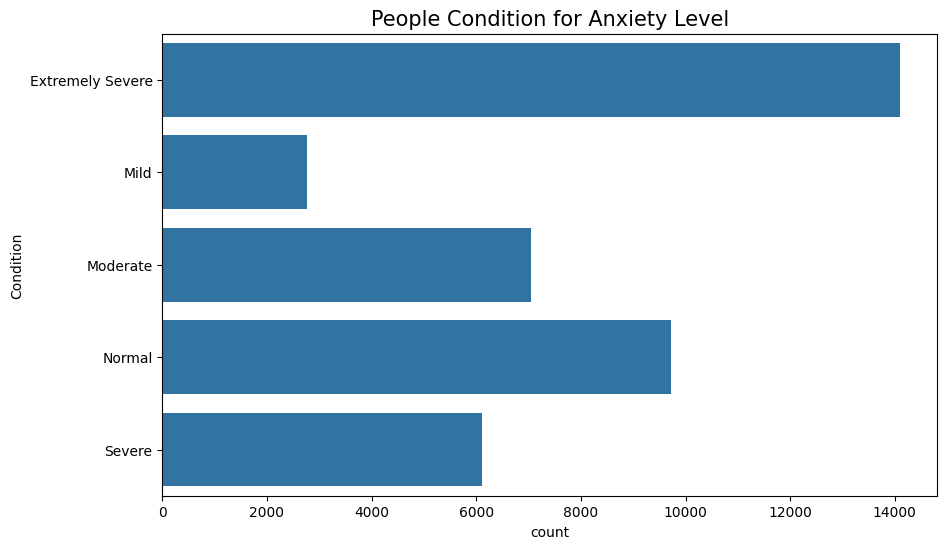

In [ ]:
plt.figure(figsize=(10,6))
sns.countplot(Anxiety.sort_values('Condition').Condition)
plt.title('People Condition for Anxiety Level',fontsize=15)

In [ ]:
Anx=Anxiety.copy()
def condition(x):
    if x<=9:
        return 0
    if  10<=x<=13:
        return 1
    if 14<=x<=20:
        return 2
    if 21<=x<=27:
        return 3
    if x>28:
        return 4

def cond(x):
    if x<=10:
        return 0
    if  10<=x<=16:
        return 1
    if 17<=x<=21:
        return 2
    if 21<=x<=35:
        return 3
    if 36<=x<=48:
        return 4
    if x>=49:
        return 5
Anx['Condition']=Anx['Total_Count'].apply(condition)
Anx['Age_Groups']=Anx['age'].apply(cond)
Anx=Anx.drop(columns=['age','Total_Count'])
Anx.head()

,Q2A,Q4A,Q7A,Q9A,Q15A,Q19A,Q20A,Q23A,Q25A,Q28A,Q30A,Q36A,Q40A,Q41A,Extraverted-enthusiastic,Critical-quarrelsome,Dependable-self_disciplined,Anxious-easily upset,Open to new experiences-complex,Reserved-quiet,Sympathetic-warm,Disorganized-careless,Calm-emotionally_stable,Conventional-uncreative,education,urban,gender,religion,race,married,familysize,Condition,Age_Groups
0,3,3,3,1,3,2,2,3,3,2,1,3,2,3,1,5,7,7,7,7,7,5,1,1,2,3,2,12,10,1,2,4.0,1
1,0,2,2,2,2,0,0,0,1,3,2,2,0,1,6,5,4,7,5,4,7,7,1,5,2,3,2,7,70,1,4,2.0,1
2,0,0,0,1,3,1,0,1,1,0,1,3,1,0,2,5,2,2,5,6,5,5,3,2,2,3,2,4,60,1,3,1.0,2
3,2,0,3,2,1,0,1,0,0,0,2,0,3,3,1,1,7,4,6,4,6,1,6,1,1,3,2,4,70,1,5,2.0,1
4,1,3,3,3,3,3,3,3,3,3,3,3,3,3,2,5,3,6,5,5,5,6,3,3,3,2,2,10,10,1,4,4.0,2


In [ ]:
# Import required libraries
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay, accuracy_score, precision_score,
    recall_score, f1_score, classification_report
)
import numpy as np
import matplotlib.pyplot as plt
from imblearn.over_sampling import SMOTE
from sklearn.decomposition import PCA
from sklearn.preprocessing import MinMaxScaler
from sklearn.utils import shuffle
from sklearn.model_selection import train_test_split

# Shuffle the dataset
Anxiety = shuffle(Anxiety, random_state=42)

# Splitting features and target
X = Anxiety.iloc[:, :-1]  # Features
y = Anxiety.iloc[:, -1]    # Target

# Splitting into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=0
)

# Apply Min-Max Scaling
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#Apply SMOTE before PCA
from imblearn.combine import SMOTEENN
smote_enn = SMOTEENN(random_state=42)
X_train_resampled, y_train_resampled = smote_enn.fit_resample(X_train_scaled, y_train)

#Apply PCA after SMOTE
pca = PCA(n_components=0.95)  # Retain 95% variance
X_train_pca = pca.fit_transform(X_train_resampled)
X_test_pca = pca.transform(X_test_scaled)

from collections import Counter
print("Before SMOTE:", Counter(y_train))
print("After SMOTE:", Counter(y_train_resampled))

print("Explained Variance Ratio:", np.sum(pca.explained_variance_ratio_))

print("Original feature count:", X_train.shape[1])
print("Reduced feature count after PCA:", X_train_pca.shape[1])



Before SMOTE: Counter({'Extremely Severe': 10579, 'Normal': 7287, 'Moderate': 5281, 'Severe': 4581, 'Mild': 2071})
After SMOTE: Counter({'Mild': 10352, 'Normal': 8910, 'Severe': 8818, 'Extremely Severe': 7716, 'Moderate': 7706})
Explained Variance Ratio: 0.9519127194412724
Original feature count: 33
Reduced feature count after PCA: 26


Best Parameters: {'C': 10, 'max_iter': 100, 'solver': 'lbfgs'}
Cross-Validation Scores: [0.99908057 0.99988507 0.99850575 0.99896552 0.99931034]
Mean CV Score: 0.9991494490658359
Accuracy: 0.977
F1 Score: 0.977
Recall Score: 0.977
Precision Score: 0.98
Error Rate: 0.023
Cohen's Kappa Score: 0.969
ROC Area (AUC-ROC): 1.0
                  precision    recall  f1-score   support

Extremely Severe     1.0000    0.9345    0.9661      3527
            Mild     1.0000    1.0000    1.0000       691
        Moderate     1.0000    1.0000    1.0000      1760
          Normal     1.0000    1.0000    1.0000      2429
          Severe     0.8686    1.0000    0.9297      1527

        accuracy                         0.9767      9934
       macro avg     0.9737    0.9869    0.9792      9934
    weighted avg     0.9798    0.9767    0.9772      9934



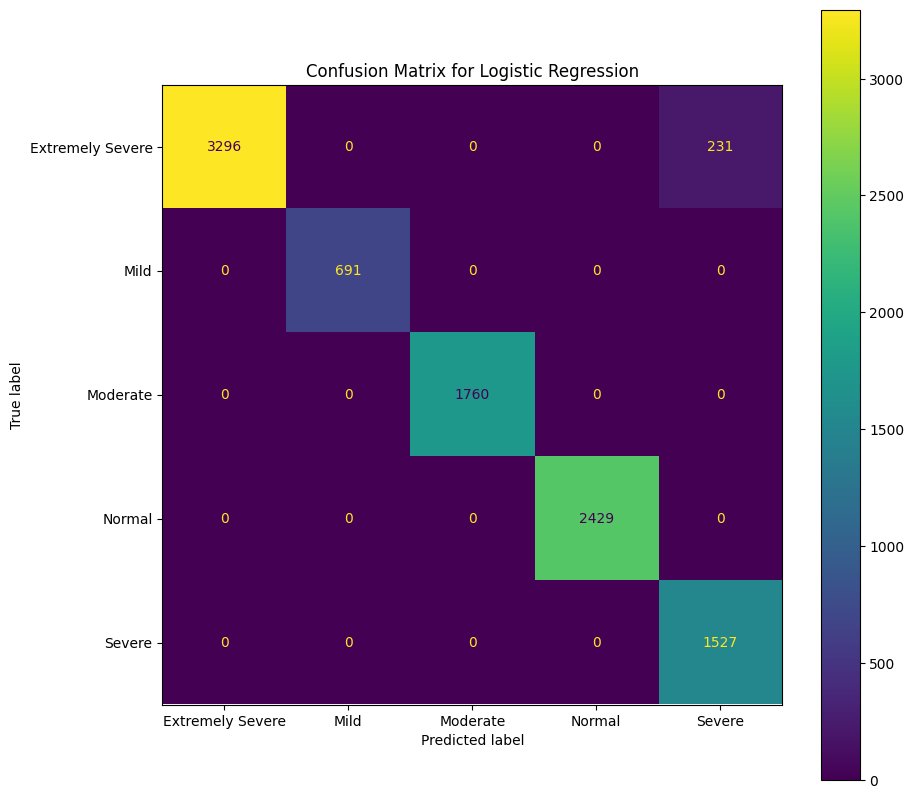

In [ ]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import cohen_kappa_score, roc_auc_score
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

#Define hyperparameter grid for GridSearchCV
param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10],  # Regularization strength
    'max_iter': [100,200,500,100],  # Maximum iterations (as per IEEE paper)
    'solver': ['lbfgs'],  # LBFGS solver (as per IEEE paper)
}

#Initialize Logistic Regression
log_reg = LogisticRegression(random_state=42, class_weight='balanced',penalty="l2")

#Perform GridSearchCV with cross-validation
grid_search = GridSearchCV(
    estimator=log_reg,
    param_grid=param_grid,
    cv=skf,  # 5-fold cross-validation (as per IEEE paper)
    scoring='accuracy',  # Optimize for accuracy
    n_jobs=-1  # Use all CPU cores
)

#Fit the model with correctly preprocessed data
grid_search.fit(X_train_pca, y_train_resampled)

#Best parameters and model
print("Best Parameters:", grid_search.best_params_)
best_log_reg = grid_search.best_estimator_

# Cross-validation score on the training set
cv_scores = cross_val_score(best_log_reg, X_train_pca, y_train_resampled, cv=5)
print("Cross-Validation Scores:", cv_scores)
print("Mean CV Score:", np.mean(cv_scores))

# Make predictions on the test set
y_pred = best_log_reg.predict(X_test_pca)

#Calculate evaluation metrics
Acc_lr = round(accuracy_score(y_test, y_pred), 3)
f1_lr = round(f1_score(y_test, y_pred, average='weighted'), 3)
recall_lr = round(recall_score(y_test, y_pred, average='weighted'), 3)
precision_lr = round(precision_score(y_test, y_pred, average='weighted'), 3)

#Print evaluation metrics
print('Accuracy:', Acc_lr)
print('F1 Score:', f1_lr)
print('Recall Score:', recall_lr)
print('Precision Score:', precision_lr)

# Compute Error Rate
error_rate = round(1 - Acc_lr, 3)
print("Error Rate:", error_rate)

# Compute Cohen's Kappa Score
kappa = round(cohen_kappa_score(y_test, y_pred), 3)
print("Cohen's Kappa Score:", kappa)

# Compute ROC Area (AUC-ROC)
# For binary classification, use y_pred_proba[:, 1] for positive class probability
# For multiclass classification, use 'ovr' (one-vs-rest) strategy
if len(set(y_test)) == 2:  # Binary classification
    y_pred_proba = best_log_reg.predict_proba(X_test_pca)[:, 1]
    roc_auc = round(roc_auc_score(y_test, y_pred_proba), 3)
else:  # Multiclass classification
    y_pred_proba = best_log_reg.predict_proba(X_test_pca)
    roc_auc = round(roc_auc_score(y_test, y_pred_proba, multi_class="ovr"), 3)

print("ROC Area (AUC-ROC):", roc_auc)


#Classification report
classification = classification_report(y_test, y_pred, digits=4)
print(classification)

#Confusion matrix and display
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(10, 10))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=best_log_reg.classes_)
disp.plot(cmap='viridis', ax=ax)
plt.title("Confusion Matrix for Logistic Regression")
plt.show()


🔹 Gaussian Naïve Bayes Performance Metrics 🔹
Accuracy: 0.86
F1 Score: 0.868
Recall Score: 0.86
Precision Score: 0.894
Cohen's Kappa Score: 0.817
ROC Area (AUC-ROC): 0.984
Error Rate: 0.14
Cross Validation Score: 0.921

🔹 Classification Report 🔹
                  precision    recall  f1-score   support

Extremely Severe     0.9787    0.9008    0.9381      3527
            Mild     0.4846    0.8625    0.6205       691
        Moderate     0.8984    0.7636    0.8256      1760
          Normal     0.9864    0.8361    0.9051      2429
          Severe     0.7310    0.9109    0.8111      1527

        accuracy                         0.8596      9934
       macro avg     0.8158    0.8548    0.8201      9934
    weighted avg     0.8939    0.8596    0.8685      9934



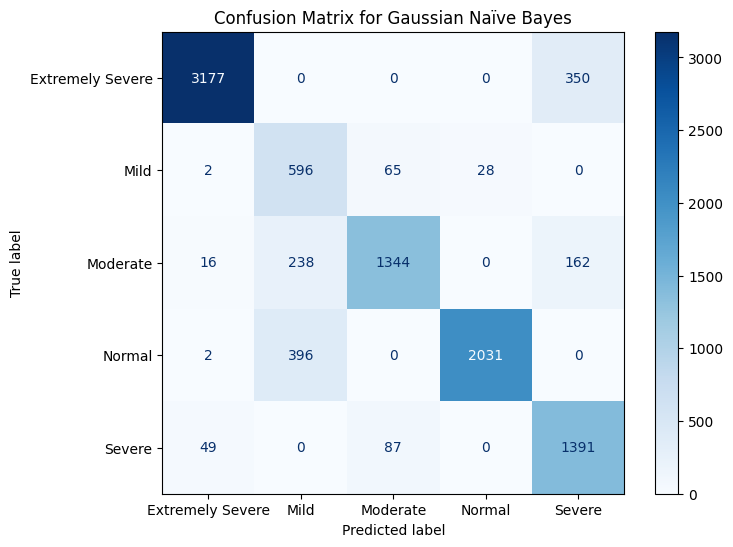

In [ ]:
# Import necessary libraries
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay, accuracy_score, precision_score,
    recall_score, f1_score, classification_report
)
from sklearn.model_selection import cross_val_score
from sklearn.metrics import cohen_kappa_score, roc_auc_score
import numpy as np
import matplotlib.pyplot as plt

#Initialize and train Gaussian Naïve Bayes model on PCA-transformed & SMOTE-applied data
gnb = GaussianNB()
gnb.fit(X_train_pca, y_train_resampled)

#Predictions on PCA-transformed test data
y_pred_gnb = gnb.predict(X_test_pca)

#Calculate evaluation metrics
Acc_gnb = round(accuracy_score(y_test, y_pred_gnb), 3)
f1_gnb = round(f1_score(y_test, y_pred_gnb, average='weighted'), 3)
recall_gnb = round(recall_score(y_test, y_pred_gnb, average='weighted'), 3)
precision_gnb = round(precision_score(y_test, y_pred_gnb, average='weighted'), 3)
error_rate_gnb = round(1 - Acc_gnb, 3)  # Error rate = 1 - Accuracy
kappa_gnb = round(cohen_kappa_score(y_test, y_pred_gnb), 3)  # Cohen’s Kappa

# Compute ROC-AUC (For multiclass classification, use `ovr` strategy)
roc_auc_gnb = round(roc_auc_score(y_test, gnb.predict_proba(X_test_pca), multi_class='ovr'), 3)

#Print evaluation results
print("🔹 Gaussian Naïve Bayes Performance Metrics 🔹")
print(f"Accuracy: {Acc_gnb}")
print(f"F1 Score: {f1_gnb}")
print(f"Recall Score: {recall_gnb}")
print(f"Precision Score: {precision_gnb}")
print(f"Cohen's Kappa Score: {kappa_gnb}")
print(f"ROC Area (AUC-ROC): {roc_auc_gnb}")
print(f"Error Rate: {error_rate_gnb}")

#Perform Cross-Validation on PCA-transformed data
cv_score_gnb = round(np.mean(cross_val_score(gnb, X_train_pca, y_train_resampled, cv=6)), 3)
print(f"Cross Validation Score: {cv_score_gnb}")

#Print classification report
print("\n🔹 Classification Report 🔹")
print(classification_report(y_test, y_pred_gnb, digits=4))

error_rate_gnb = round(1 - Acc_gnb, 3)  # Error rate = 1 - Accuracy
kappa_gnb = round(cohen_kappa_score(y_test, y_pred_gnb), 3)  # Cohen’s Kappa

# Compute ROC-AUC (For multiclass classification, use `ovr` strategy)
roc_auc_gnb = round(roc_auc_score(y_test, gnb.predict_proba(X_test_pca), multi_class='ovr'), 3)

#Confusion Matrix Visualization
cm_gnb = confusion_matrix(y_test, y_pred_gnb)
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_gnb, display_labels=gnb.classes_)
disp.plot(cmap="Blues", ax=ax)
plt.title("Confusion Matrix for Gaussian Naïve Bayes")
plt.show()


/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_search.py:1108: UserWarning: One or more of the test scores are non-finite: [       nan 0.97046898        nan 0.96621011        nan 0.96199932
        nan 0.9525938  0.96690836 0.97843665 0.9501189  0.97233607
 0.92699303 0.96710826 0.91378939 0.95426646]
  warnings.warn(



🔹 K-Nearest Neighbors Performance Metrics 🔹
Best Parameters: {'metric': 'euclidean', 'n_neighbors': 5, 'weights': 'distance'}
Accuracy: 0.73
F1 Score: 0.749
Recall Score: 0.73
Precision Score: 0.8
Error Rate: 0.27
ROC Area (AUC-ROC): 0.907
Cohen's Kappa Score: 0.654
Cross Validation Score: 0.978

🔹 Classification Report 🔹
                  precision    recall  f1-score   support

Extremely Severe     0.9977    0.7479    0.8550      3527
            Mild     0.3267    0.6628    0.4376       691
        Moderate     0.6490    0.5210    0.5780      1760
          Normal     0.9345    0.8514    0.8910      2429
          Severe     0.5164    0.7649    0.6165      1527

        accuracy                         0.7297      9934
       macro avg     0.6848    0.7096    0.6756      9934
    weighted avg     0.7998    0.7297    0.7490      9934



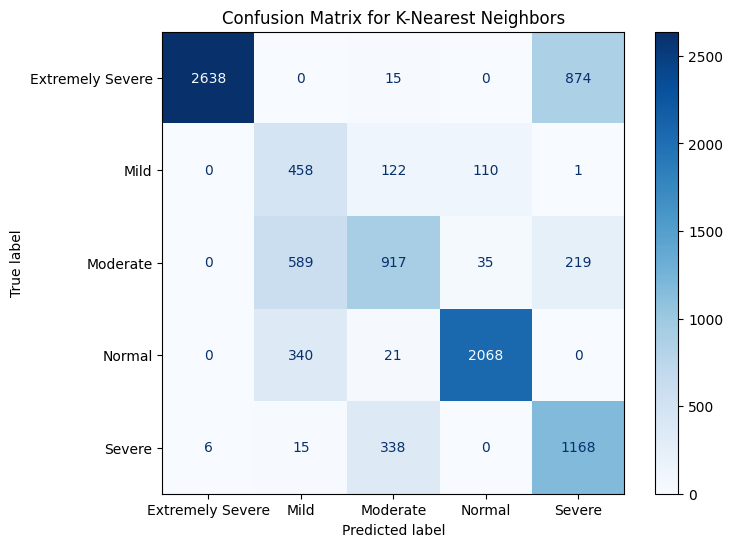

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay, roc_auc_score, cohen_kappa_score
)
import numpy as np
import matplotlib.pyplot as plt

# Define hyperparameter grid for KNN
param_grid = {
    'n_neighbors': [5,7,10,15],  # Number of neighbors
    'weights': ['uniform', 'distance'],  # Voting strategy
    'metric': ['manhattan','euclidean']  # Distance metric
}

# Initialize KNN classifier
knn = KNeighborsClassifier()

# Perform GridSearchCV
grid_search_knn = GridSearchCV(
    estimator=knn,
    param_grid=param_grid,
    cv=5,  # 5-fold cross-validation
    scoring='f1_weighted',  # Optimize for F1-score
    n_jobs=-1
)

# Train the KNN model using PCA-transformed and SMOTE-resampled data
grid_search_knn.fit(X_train_pca, y_train_resampled)

# Get the best model
best_knn = grid_search_knn.best_estimator_

# Predict on the test set
y_pred_knn = best_knn.predict(X_test_pca)

# Calculate evaluation metrics
Acc_knn = round(accuracy_score(y_test, y_pred_knn), 3)
f1_knn = round(f1_score(y_test, y_pred_knn, average='weighted'), 3)
recall_knn = round(recall_score(y_test, y_pred_knn, average='weighted'), 3)
precision_knn = round(precision_score(y_test, y_pred_knn, average='weighted'), 3)
error_rate_knn = round(1 - Acc_knn, 3)  # Error Rate

# Compute ROC-AUC (requires probability estimates)
y_pred_prob_knn = best_knn.predict_proba(X_test_pca)
roc_auc_knn = round(roc_auc_score(y_test, y_pred_prob_knn, multi_class='ovr'), 3)

# Compute Cohen's Kappa Score
kappa_knn = round(cohen_kappa_score(y_test, y_pred_knn), 3)

# Print evaluation metrics
print("\n🔹 K-Nearest Neighbors Performance Metrics 🔹")
print(f"Best Parameters: {grid_search_knn.best_params_}")
print(f"Accuracy: {Acc_knn}")
print(f"F1 Score: {f1_knn}")
print(f"Recall Score: {recall_knn}")
print(f"Precision Score: {precision_knn}")
print(f"Error Rate: {error_rate_knn}")
print(f"ROC Area (AUC-ROC): {roc_auc_knn}")
print(f"Cohen's Kappa Score: {kappa_knn}")

# Cross-validation Score
cv_score_knn = round(np.mean(cross_val_score(best_knn, X_train_pca, y_train_resampled, cv=5)), 3)
print(f"Cross Validation Score: {cv_score_knn}")

# Classification Report
print("\n🔹 Classification Report 🔹")
print(classification_report(y_test, y_pred_knn, digits=4))

# Confusion Matrix Visualization
cm_knn = confusion_matrix(y_test, y_pred_knn)
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_knn, display_labels=best_knn.classes_)
disp.plot(cmap="Blues", ax=ax)
plt.title("Confusion Matrix for K-Nearest Neighbors")
plt.show()


Training Kappa Score (RBFN): 0.9981
🔹 Radial Basis Function Network (RBFN) Performance Metrics 🔹
Accuracy: 0.95
F1 Score: 0.952
Recall Score: 0.95
Precision Score: 0.959
Cross Validation Score: 0.995

🔹 Classification Report 🔹
                  precision    recall  f1-score   support

Extremely Severe     1.0000    0.9172    0.9568      3527
            Mild     0.7995    0.9986    0.8880       691
        Moderate     0.9936    0.9722    0.9828      1760
          Normal     1.0000    0.9407    0.9695      2429
          Severe     0.8294    0.9935    0.9041      1527

        accuracy                         0.9501      9934
       macro avg     0.9245    0.9644    0.9402      9934
    weighted avg     0.9587    0.9501    0.9516      9934

Error Rate: 0.05
Cohen's Kappa Score: 0.935
ROC Area (AUC-ROC): 1.0


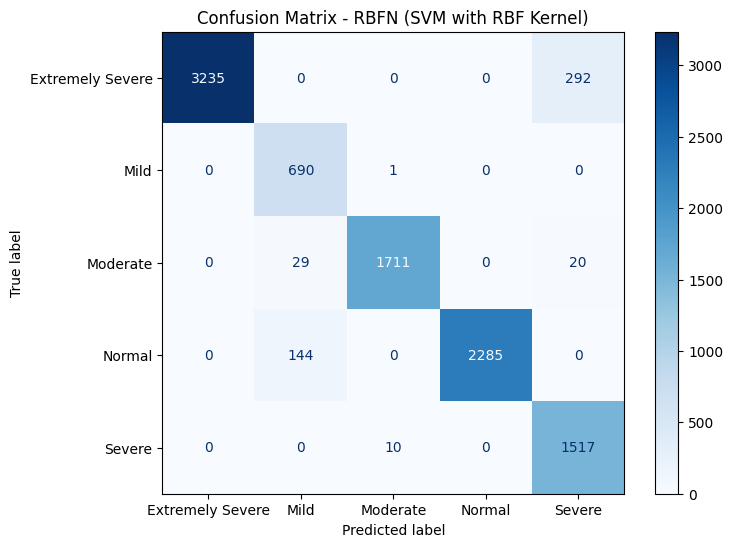

In [ ]:
# Import necessary libraries
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_val_score

#Initialize and train SVM with RBF kernel (RBFN)

rbfn = SVC(kernel='rbf', C=0.5, gamma='scale', class_weight='balanced',probability=True, random_state=42)
rbfn.fit(X_train_pca, y_train_resampled)  # Train on SMOTE-applied PCA data

#Make predictions on PCA-transformed test data
y_pred_rbfn = rbfn.predict(X_test_pca)

y_train_pred_rbfn = rbfn.predict(X_train_pca)
# Compute and print Kappa score
kappa_train_rbfn = cohen_kappa_score(y_train_resampled, y_train_pred_rbfn)
print(f"Training Kappa Score (RBFN): {kappa_train_rbfn:.4f}")

#Compute evaluation metrics
Acc_rbfn = round(accuracy_score(y_test, y_pred_rbfn), 3)
f1_rbfn = round(f1_score(y_test, y_pred_rbfn, average='weighted'), 3)
recall_rbfn = round(recall_score(y_test, y_pred_rbfn, average='weighted'), 3)
precision_rbfn = round(precision_score(y_test, y_pred_rbfn, average='weighted'), 3)
error_rate_rbfn = round(1 - Acc_rbfn, 3)  # Error rate = 1 - Accuracy
kappa_rbfn = round(cohen_kappa_score(y_test, y_pred_rbfn), 3)  # Cohen’s Kappa Score

# Compute ROC-AUC (For multiclass classification, use `ovr` strategy)
roc_auc_rbfn = round(roc_auc_score(y_test, rbfn.predict_proba(X_test_pca), multi_class='ovr'), 3)


#Print evaluation results
print("🔹 Radial Basis Function Network (RBFN) Performance Metrics 🔹")
print(f"Accuracy: {Acc_rbfn}")
print(f"F1 Score: {f1_rbfn}")
print(f"Recall Score: {recall_rbfn}")
print(f"Precision Score: {precision_rbfn}")

#Perform Cross-Validation
cv_score_rbfn = round(np.mean(cross_val_score(rbfn, X_train_pca, y_train_resampled, cv=5)), 3)
print(f"Cross Validation Score: {cv_score_rbfn}")

#Print classification report
print("\n🔹 Classification Report 🔹")
print(classification_report(y_test, y_pred_rbfn, digits=4))
print(f"Error Rate: {error_rate_rbfn}")
print(f"Cohen's Kappa Score: {kappa_rbfn}")
print(f"ROC Area (AUC-ROC): {roc_auc_rbfn}")

#Confusion Matrix Visualization
cm_rbfn = confusion_matrix(y_test, y_pred_rbfn)
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_rbfn, display_labels=rbfn.classes_)
disp.plot(cmap="Blues", ax=ax)
plt.title("Confusion Matrix - RBFN (SVM with RBF Kernel)")
plt.show()


🔹 Best Parameters: {'criterion': 'entropy', 'max_depth': 10, 'min_samples_leaf': 5, 'min_samples_split': 5}
Best ccp_alpha: 0.00010402185875390285

🔹 Decision Tree Performance Metrics 🔹
Accuracy: 0.925
F1 Score: 0.928
Recall Score: 0.925
Precision Score: 0.936
Error Rate: 0.075
Cohen's Kappa Score: 0.902
ROC Area (AUC-ROC): 0.976
Cross Validation Score: 0.974

🔹 Classification Report 🔹
                  precision    recall  f1-score   support

Extremely Severe     0.9961    0.9399    0.9672      3527
            Mild     0.6652    0.9059    0.7672       691
        Moderate     0.9395    0.8824    0.9100      1760
          Normal     0.9873    0.9259    0.9556      2429
          Severe     0.8362    0.9496    0.8893      1527

        accuracy                         0.9254      9934
       macro avg     0.8849    0.9207    0.8979      9934
    weighted avg     0.9363    0.9254    0.9283      9934



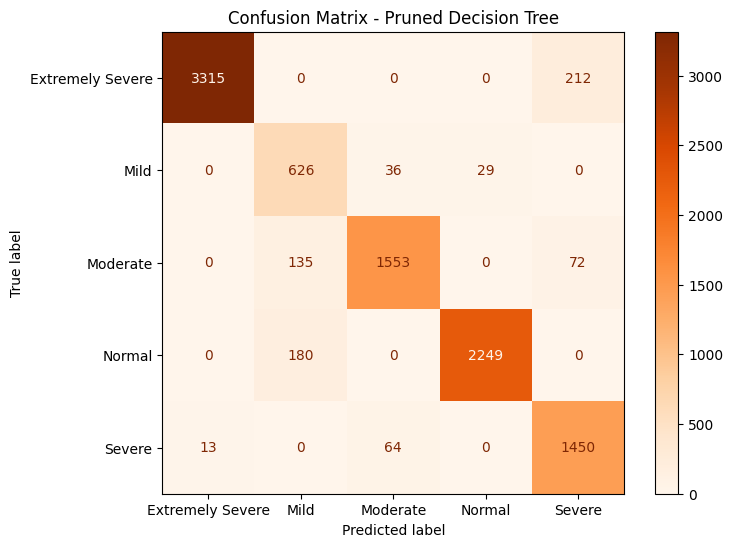

Training Accuracy: 0.9864
Test Accuracy: 0.9254


In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)
import numpy as np
import matplotlib.pyplot as plt

# Initialize Decision Tree Classifier
dt = DecisionTreeClassifier(random_state=42)

#Expanded Hyperparameter Grid to Reduce Overfitting
param_grid = {
    "criterion": ["gini", "entropy"],
    "max_depth": [6, 8, 10],  # Reduced depth to avoid overfitting
    "min_samples_split": [5, 10, 15],  # Encourage generalization
    "min_samples_leaf": [5, 10]  # Force larger leaf sizes
}

#Perform Grid Search with Cross-Validation
grid_search = GridSearchCV(
    estimator=dt,
    param_grid=param_grid,
    cv=5,
    scoring="f1_weighted",
    n_jobs=-1
)

grid_search.fit(X_train_pca, y_train_resampled)

#Best Model Selection
best_dt = grid_search.best_estimator_
print(f"🔹 Best Parameters: {grid_search.best_params_}")

#Cost Complexity Pruning
path = best_dt.cost_complexity_pruning_path(X_train_pca, y_train_resampled)
ccp_alphas = path.ccp_alphas[:-1]  # Exclude last max alpha (pruning all nodes)

pruned_models = [DecisionTreeClassifier(ccp_alpha=alpha).fit(X_train_pca, y_train_resampled) for alpha in ccp_alphas]
val_scores = [accuracy_score(y_test, model.predict(X_test_pca)) for model in pruned_models]

best_alpha = ccp_alphas[np.argmax(val_scores)]
print(f"Best ccp_alpha: {best_alpha}")

# Train Final Model with Best Pruning Level
pruned_dt = DecisionTreeClassifier(ccp_alpha=best_alpha, **grid_search.best_params_)
pruned_dt.fit(X_train_pca, y_train_resampled)

#Make Predictions
y_pred_dt = pruned_dt.predict(X_test_pca)

#Evaluation Metrics
Acc_dt = round(accuracy_score(y_test, y_pred_dt), 3)
f1_dt = round(f1_score(y_test, y_pred_dt, average="weighted"), 3)
recall_dt = round(recall_score(y_test, y_pred_dt, average="weighted"), 3)
precision_dt = round(precision_score(y_test, y_pred_dt, average="weighted"), 3)
error_rate_dt = round(1 - Acc_dt, 3)  # Error rate = 1 - Accuracy
kappa_dt = round(cohen_kappa_score(y_test, y_pred_dt), 3)  # Cohen’s Kappa Score

# Compute ROC-AUC (For multiclass classification, use `ovr` strategy)
roc_auc_dt = round(roc_auc_score(y_test, pruned_dt.predict_proba(X_test_pca), multi_class='ovr'), 3)

#Print Performance Metrics
print("\n🔹 Decision Tree Performance Metrics 🔹")
print(f"Accuracy: {Acc_dt}")
print(f"F1 Score: {f1_dt}")
print(f"Recall Score: {recall_dt}")
print(f"Precision Score: {precision_dt}")
print(f"Error Rate: {error_rate_dt}")
print(f"Cohen's Kappa Score: {kappa_dt}")
print(f"ROC Area (AUC-ROC): {roc_auc_dt}")

#Cross-Validation Score
cv_score_dt = round(np.mean(cross_val_score(pruned_dt, X_train_pca, y_train_resampled, cv=6)), 3)
print(f"Cross Validation Score: {cv_score_dt}")

#Classification Report
print("\n🔹 Classification Report 🔹")
print(classification_report(y_test, y_pred_dt, digits=4))

#Confusion Matrix Visualization
cm_dt = confusion_matrix(y_test, y_pred_dt)
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_dt, display_labels=pruned_dt.classes_)
disp.plot(cmap="Oranges", ax=ax)
plt.title("Confusion Matrix - Pruned Decision Tree")
plt.show()

#Compare Train vs Test Accuracy
y_train_pred = pruned_dt.predict(X_train_pca)
train_acc = accuracy_score(y_train_resampled, y_train_pred)
test_acc = accuracy_score(y_test, y_pred_dt)
print(f"Training Accuracy: {train_acc:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 1 is smaller than n_iter=10. Running 1 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


🔹 Best Parameters: {'n_estimators': 150, 'min_samples_split': 7, 'min_samples_leaf': 5, 'max_features': 'sqrt', 'max_depth': 10, 'ccp_alpha': 0.02}

🔹 Random Forest Performance Metrics 🔹
Accuracy: 0.872
F1 Score: 0.88
Recall Score: 0.872
Precision Score: 0.903
Error Rate: 0.128
Cohen's Kappa Score: 0.833
ROC Area (AUC-ROC): 0.973
Cross Validation Score: 0.933

🔹 Classification Report 🔹
                  precision    recall  f1-score   support

Extremely Severe     0.9944    0.8982    0.9438      3527
            Mild     0.5071    0.8784    0.6430       691
        Moderate     0.9044    0.7688    0.8311      1760
          Normal     0.9829    0.8732    0.9248      2429
          Severe     0.7433    0.9234    0.8236      1527

        accuracy                         0.8717      9934
       macro avg     0.8264    0.8684    0.8333      9934
    weighted avg     0.9031    0.8717    0.8798      9934



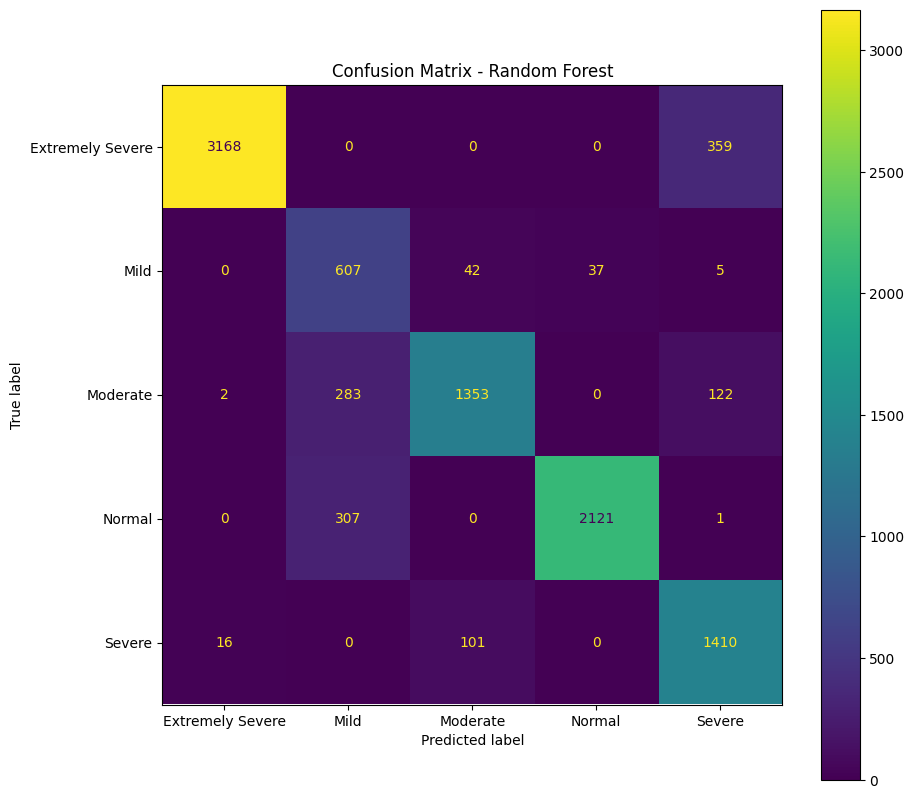

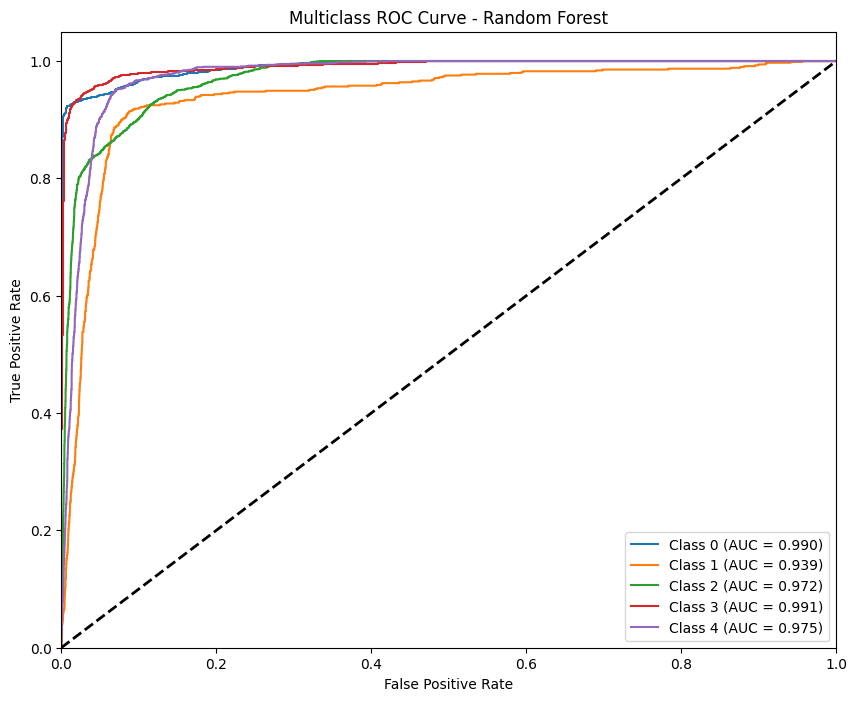

Training Accuracy: 0.9341


In [ ]:
#Import Required Libraries
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV, cross_val_score
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay, roc_auc_score, cohen_kappa_score
)
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

#Updated Hyperparameter Grid
param_dist = {
    "n_estimators": [150],
    "max_depth": [10],
    "min_samples_split": [7],
    "min_samples_leaf": [5],
    "max_features": ["sqrt"],
    "ccp_alpha": [0.02]
}

# Initialize RandomForest with Balanced Class Weights
RanFor = RandomForestClassifier(random_state=42, class_weight="balanced")

#Perform Randomized Search with CV
rand_search = RandomizedSearchCV(
    estimator=RanFor,
    param_distributions=param_dist,
    n_iter=10,
    cv=5,
    scoring='f1_weighted',
    n_jobs=-1,
    random_state=42
)

#Train with Resampled Data
rand_search.fit(X_train_pca, y_train_resampled)

#Use the Best Found Model
RanFor = rand_search.best_estimator_

# Predictions on Test Set
y_pred = RanFor.predict(X_test_pca)

#Compute Performance Metrics
Acc_ran = round(accuracy_score(y_test, y_pred), 3)
f1_ran = round(f1_score(y_test, y_pred, average='weighted'), 3)
recall_ran = round(recall_score(y_test, y_pred, average='weighted'), 3)
precision_ran = round(precision_score(y_test, y_pred, average='weighted'), 3)
error_rate = round(1 - Acc_ran, 3)
kappa_score = round(cohen_kappa_score(y_test, y_pred), 3)

# AUC-ROC Score Calculation
y_test_bin = label_binarize(y_test, classes=np.unique(y_test))  # Convert to One-vs-Rest (OvR)
y_pred_prob = RanFor.predict_proba(X_test_pca)  # Get probability estimates
auc_roc = round(roc_auc_score(y_test_bin, y_pred_prob, multi_class="ovr"), 3)

# Print Model Performance
print(f"🔹 Best Parameters: {rand_search.best_params_}")
print("\n🔹 Random Forest Performance Metrics 🔹")
print(f"Accuracy: {Acc_ran}")
print(f"F1 Score: {f1_ran}")
print(f"Recall Score: {recall_ran}")
print(f"Precision Score: {precision_ran}")
print(f"Error Rate: {error_rate}")
print(f"Cohen's Kappa Score: {kappa_score}")
print(f"ROC Area (AUC-ROC): {auc_roc}")

# Cross-Validation Score
cv_score_rf = round(np.mean(cross_val_score(RanFor, X_train_pca, y_train_resampled, cv=6)), 3)
print(f"Cross Validation Score: {cv_score_rf}")

#Classification Report
print("\n🔹 Classification Report 🔹")
print(classification_report(y_test, y_pred, digits=4))

#Confusion Matrix Visualization
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(10, 10))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=RanFor.classes_)
disp.plot(cmap='viridis', ax=ax)
plt.title("Confusion Matrix - Random Forest")
plt.show()

# ROC Curve for Multiclass Classification
fpr = dict()
tpr = dict()
roc_auc = dict()
n_classes = y_test_bin.shape[1]

plt.figure(figsize=(10, 8))
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_pred_prob[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])
    plt.plot(fpr[i], tpr[i], label=f'Class {i} (AUC = {roc_auc[i]:.3f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Multiclass ROC Curve - Random Forest")
plt.legend(loc="lower right")
plt.show()

#Training Accuracy Check (to compare with test accuracy)
train_acc = accuracy_score(y_train_resampled, RanFor.predict(X_train_pca))
print(f"Training Accuracy: {train_acc:.4f}")


In [ ]:
# Import Required Libraries
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, cohen_kappa_score
import numpy as np

# Encode the labels
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train_resampled)
y_test_encoded = label_encoder.transform(y_test)

# One-Hot Encoding for ROC-AUC calculation
one_hot_encoder = OneHotEncoder(sparse_output=False)
y_test_onehot = one_hot_encoder.fit_transform(y_test_encoded.reshape(-1, 1))

# Define the ANN Model
model = Sequential([
    keras.layers.Input(shape=(X_train_pca.shape[1],)),  # Explicit Input layer
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dense(len(np.unique(y_train_encoded)), activation='softmax')  # Output Layer
])

# Compile the Model
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Implement Early Stopping (if validation loss increases for 5 epochs, stop training)
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1)

# Train the Model (Removed Cross-Validation)
history = model.fit(X_train_pca, y_train_encoded, epochs=50, batch_size=32,
                    validation_data=(X_test_pca, y_test_encoded), callbacks=[early_stopping])

# Predictions
y_pred_ann = np.argmax(model.predict(X_test_pca), axis=1)

# Evaluation Metrics
accuracy_ann = round(accuracy_score(y_test_encoded, y_pred_ann), 3)
error_rate_ann = round(1 - accuracy_ann, 3)
kappa_ann = round(cohen_kappa_score(y_test_encoded, y_pred_ann), 3)
auc_roc_ann = round(roc_auc_score(y_test_onehot, model.predict(X_test_pca)), 3)  # Multi-class ROC-AUC

# Print Performance Metrics
print("\n🔹 ANN Performance Metrics 🔹")
print(f"Accuracy: {accuracy_ann}")
print(f"Error Rate: {error_rate_ann}")
print(f"Cohen's Kappa Score: {kappa_ann}")
print(f"ROC Area (AUC-ROC): {auc_roc_ann}")

print("\n🔹 ANN Classification Report 🔹")
report_dict = classification_report(y_test_encoded, y_pred_ann, output_dict=True, digits=4)
print(report_dict)
precision_ann = round(report_dict['macro avg']['precision'], 3)
recall_ann = round(report_dict['macro avg']['recall'], 3)
f1_score_ann = round(report_dict['macro avg']['f1-score'], 3)


Epoch 1/50
1360/1360 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.7743 - loss: 0.5464 - val_accuracy: 0.9607 - val_loss: 0.1030
Epoch 2/50
1360/1360 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9620 - loss: 0.1012 - val_accuracy: 0.9584 - val_loss: 0.1021
Epoch 3/50
1360/1360 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9803 - loss: 0.0570 - val_accuracy: 0.9515 - val_loss: 0.1520
Epoch 4/50
1360/1360 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9858 - loss: 0.0413 - val_accuracy: 0.9842 - val_loss: 0.0424
Epoch 5/50
1360/1360 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9909 - loss: 0.0272 - val_accuracy: 0.9838 - val_loss: 0.0421
Epoch 6/50
1360/1360 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9913 - loss: 0.0250 - val_accuracy: 0.9850 - val_loss: 0.0380
Epoch 7/50
1360/1360 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9919 - loss: 0.0227 - val_accuracy: 0.9785 - val_loss: 0.0573
Epoch 8/50
1360/1360 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9936 - loss: 0.0189 -